In [1]:

#########################################################
#get numeric data: df_numerics

#get numeric columns: col_names_numeric

#boxplot df_numerics

# 3 Exploratory Data Analysis<a id='3_Exploratory_Data_Analysis'></a>

## 3.1 Contents<a id='3.1_Contents'></a>
* [3 Exploratory Data Analysis](#3_Exploratory_Data_Analysis)
  * [3.1 Contents](#3.1_Contents)
  * [3.2 Introduction](#3.2_Introduction)
  * [3.3 Imports](#3.3_Imports)
  * [3.4 Load The Data](#3.4_Load_The_Data)
    * [3.4.1 Ski data](#3.4.1_Ski_data)
    * [3.4.2 State-wide summary data](#3.4.2_State-wide_summary_data)
  * [3.5 Explore The Data](#3.5_Explore_The_Data)
    * [3.5.1 Top States By Order Of Each Of The Summary Statistics](#3.5.1_Top_States_By_Order_Of_Each_Of_The_Summary_Statistics)
      * [3.5.1.1 Total state area](#3.5.1.1_Total_state_area)
      * [3.5.1.2 Total state population](#3.5.1.2_Total_state_population)
      * [3.5.1.3 Resorts per state](#3.5.1.3_Resorts_per_state)
      * [3.5.1.4 Total skiable area](#3.5.1.4_Total_skiable_area)
      * [3.5.1.5 Total night skiing area](#3.5.1.5_Total_night_skiing_area)
      * [3.5.1.6 Total days open](#3.5.1.6_Total_days_open)
    * [3.5.2 Resort density](#3.5.2_Resort_density)
      * [3.5.2.1 Top states by resort density](#3.5.2.1_Top_states_by_resort_density)
    * [3.5.3 Visualizing High Dimensional Data](#3.5.3_Visualizing_High_Dimensional_Data)
      * [3.5.3.1 Scale the data](#3.5.3.1_Scale_the_data)
        * [3.5.3.1.1 Verifying the scaling](#3.5.3.1.1_Verifying_the_scaling)
      * [3.5.3.2 Calculate the PCA transformation](#3.5.3.2_Calculate_the_PCA_transformation)
      * [3.5.3.3 Average ticket price by state](#3.5.3.3_Average_ticket_price_by_state)
      * [3.5.3.4 Adding average ticket price to scatter plot](#3.5.3.4_Adding_average_ticket_price_to_scatter_plot)
    * [3.5.4 Conclusion On How To Handle State Label](#3.5.4_Conclusion_On_How_To_Handle_State_Label)
    * [3.5.5 Ski Resort Numeric Data](#3.5.5_Ski_Resort_Numeric_Data)
      * [3.5.5.1 Feature engineering](#3.5.5.1_Feature_engineering)
      * [3.5.5.2 Feature correlation heatmap](#3.5.5.2_Feature_correlation_heatmap)
      * [3.5.5.3 Scatterplots of numeric features against ticket price](#3.5.5.3_Scatterplots_of_numeric_features_against_ticket_price)
  * [3.6 Summary](#3.6_Summary)


## 3.2 Introduction<a id='3.2_Introduction'></a>

At this point, you should have a firm idea of what your data science problem is and have the data you believe could help solve it. The business problem was a general one of modeling resort revenue. The data you started with contained some ticket price values, but with a number of missing values that led to several rows being dropped completely. You also had two kinds of ticket price. There were also some obvious issues with some of the other features in the data that, for example, led to one column being completely dropped, a data error corrected, and some other rows dropped. You also obtained some additional US state population and size data with which to augment the dataset, which also required some cleaning.

The data science problem you subsequently identified is to predict the adult weekend ticket price for ski resorts.

## 3.3 Imports<a id='3.3_Imports'></a>

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale


pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

pd.set_option('display.max_colwidth', None)



## 3.4 Load The Data<a id='3.4_Load_The_Data'></a>

### 3.4.1 Ski data<a id='3.4.1_Ski_data'></a>

In [3]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)

In [4]:
df = rcp('21boxscoreadvancedv2_boxscores_team_away_home_2010_2018.csv')
p(df)

(10266, 107)


,game_id,game_date,TEAM_NAME_away,TEAM_ABBREVIATION_away,TEAM_CITY_away,MIN_away,duration_away,TEAM_NAME_home,TEAM_ABBREVIATION_home,TEAM_CITY_home,MIN_home,duration_home,E_OFF_RATING_away,OFF_RATING_away,E_DEF_RATING_away,DEF_RATING_away,E_NET_RATING_away,NET_RATING_away,AST_PCT_away,AST_TOV_away,AST_RATIO_away,OREB_PCT_away,DREB_PCT_away,REB_PCT_away,E_TM_TOV_PCT_away,TM_TOV_PCT_away,EFG_PCT_away,TS_PCT_away,USG_PCT_away,E_USG_PCT_away,E_PACE_away,PACE_away,PACE_PER40_away,POSS_away,PIE_away,duration_minutes_away,E_OFF_RATING_home,OFF_RATING_home,E_DEF_RATING_home,DEF_RATING_home,E_NET_RATING_home,NET_RATING_home,AST_PCT_home,AST_TOV_home,AST_RATIO_home,OREB_PCT_home,DREB_PCT_home,REB_PCT_home,E_TM_TOV_PCT_home,TM_TOV_PCT_home,EFG_PCT_home,TS_PCT_home,USG_PCT_home,E_USG_PCT_home,E_PACE_home,PACE_home,PACE_PER40_home,POSS_home,PIE_home,duration_minutes_home,team_id_away,wl_away,w_pct_away,min_away,fgm_away,fga_away,fg_pct_away,fg3m_away,fg3a_away,fg3_pct_away,ftm_away,fta_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,wl_home,team_id_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_type,season,season_year
0,21000001,2010-10-26,Heat,MIA,Miami,240:00,0 days 04:00:00,Celtics,BOS,Boston,240:00,0 days 04:00:00,87.9,87.9,95.7,95.7,-7.7,-7.7,0.556,0.88,12.8,0.250,0.732,0.472,18.681,18.7,0.419,0.471,1.0,0.200,91.50,91.50,76.25,91,0.401,240.0,95.7,95.7,87.9,87.9,7.7,7.7,0.781,1.25,20.0,0.268,0.750,0.528,21.739,21.7,0.522,0.550,1.0,0.196,91.50,91.50,76.25,92,0.599,240.0,1610612748,L,0.000,240,27,74,0.365,8,20,0.400,18,25,0.720000,11,28,39,15,10,6,17,21,80,W,1610612738,1.000,240,32,69,0.464,8,16,0.500,16,25,0.640000,8,34,42,25,6,4,18,19,88,Regular Season,2010-11,2010
1,21000002,2010-10-26,Suns,PHX,Phoenix,240:00,0 days 04:00:00,Trail Blazers,POR,Portland,240:00,0 days 04:00:00,98.9,102.2,109.7,117.8,-10.8,-15.6,0.417,0.79,13.0,0.244,0.510,0.391,20.421,21.1,0.547,0.568,1.0,0.196,94.82,90.00,75.00,90,0.375,240.0,109.7,117.8,98.9,102.2,10.8,15.6,0.721,2.07,21.3,0.490,0.756,0.609,15.528,16.7,0.516,0.532,1.0,0.192,94.82,90.00,75.00,90,0.625,240.0,1610612756,L,0.000,240,36,74,0.486,9,19,0.474,11,16,0.687500,7,23,30,15,3,4,19,19,92,W,1610612757,1.000,240,43,93,0.462,10,20,0.500,10,15,0.666667,18,30,48,31,11,2,12,22,106,Regular Season,2010-11,2010
2,21000003,2010-10-26,Rockets,HOU,Houston,240:00,0 days 04:00:00,Lakers,LAL,Los Angeles,240:00,0 days 04:00:00,101.6,106.8,105.3,107.7,-3.8,-0.9,0.658,1.19,16.7,0.396,0.695,0.554,19.387,20.4,0.462,0.532,1.0,0.196,107.32,103.50,86.25,103,0.507,240.0,105.3,107.7,101.6,106.8,3.8,0.9,0.525,1.75,14.9,0.305,0.604,0.446,11.287,11.5,0.464,0.517,1.0,0.198,107.32,103.50,86.25,104,0.493,240.0,1610612745,L,0.000,240,38,91,0.418,8,20,0.400,26,28,0.928571,16,37,53,25,6,7,20,25,110,W,1610612747,1.000,240,40,96,0.417,9,21,0.429,23,28,0.821429,14,30,44,21,11,4,12,24,112,Regular Season,2010-11,2010
3,21000016,2010-10-27,Trail Blazers,POR,Portland,240:00,0 days 04:00:00,Clippers,LAC,Los Angeles,240:00,0 days 04:00:00,107.6,108.9,94.4,97.8,13.1,11.1,0.472,1.21,13.2,0.446,0.627,0.533,15.364,15.6,0.455,0.499,1.0,0.198,92.16,90.00,75.00,90,0.551,240.0,94.4,97.8,107.6,108.9,-13.1,-11.1,0.594,1.27,15.1,0.373,0.554,0.467,16.094,16.7,0.437,0.477,1.0,0.200,92.16,90.00,75.00,90,0.449,240.0,1610612757,W,1.000,240,36,88,0.409,8,20,0.400,18,23,0.782609,21,30,51,17,9,6,12,23,98,L,1610612746,0.000,240,32,79,0.405,5,18,0.278,19,30,0.633333,14,27,41,19,8,8,15,20,88,Regular Season,2010-11,2010
4,21000004,2010-10-27,Celtics,BOS,Boston,240:00,0 days 04:00:00,Cavaliers,CLE,Cleveland,240:00,0 days 04:00:00,92.3,94.6,97.7,103.3,-5.4,-8.7,0.706,1.26,19.3,0.225,0.708,0.489,20.161,20.7,0.493,0.535,1.0,0.198,95.74,92.00,76.67,92,0.477,240.0,97.7,103.3,92.3,94.6,5.4,8.7,0.667,1.60,18.6,0.292,0.775,0.511,15.426,16.3,0.481,0.526,1.0,0.196,95.7

In [5]:
df.value_counts('MIN_away')

MIN_away
240:00    9633
265:00     541
290:00      71
315:00      17
340:00       3
239:56       1
dtype: int64

In [6]:
pd.options.display.max_info_columns = 999
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10266 entries, 0 to 10265
Data columns (total 107 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 10266 non-null  int64  
 1   game_date               10266 non-null  object 
 2   TEAM_NAME_away          10266 non-null  object 
 3   TEAM_ABBREVIATION_away  10266 non-null  object 
 4   TEAM_CITY_away          10266 non-null  object 
 5   MIN_away                10266 non-null  object 
 6   duration_away           10266 non-null  object 
 7   TEAM_NAME_home          10266 non-null  object 
 8   TEAM_ABBREVIATION_home  10266 non-null  object 
 9   TEAM_CITY_home          10266 non-null  object 
 10  MIN_home                10266 non-null  object 
 11  duration_home           10266 non-null  object 
 12  E_OFF_RATING_away       10266 non-null  float64
 13  OFF_RATING_away         10266 non-null  float64
 14  E_DEF_RATING_away       10266 non-nul

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
game_id,10266.0,2.265576e+07,4.932984e+06,2.100000e+07,2.120035e+07,2.140045e+07,2.160056e+07,4.170040e+07
E_OFF_RATING_away,10266.0,1.026809e+02,1.128122e+01,6.070000e+01,9.510000e+01,1.027000e+02,1.103000e+02,1.476000e+02
OFF_RATING_away,10266.0,1.044408e+02,1.116980e+01,6.090000e+01,9.690000e+01,1.044000e+02,1.118000e+02,1.443000e+02
E_DEF_RATING_away,10266.0,1.057678e+02,1.114625e+01,6.570000e+01,9.820000e+01,1.057000e+02,1.133000e+02,1.516000e+02
DEF_RATING_away,10266.0,1.073958e+02,1.096775e+01,6.810000e+01,1.000000e+02,1.073000e+02,1.147000e+02,1.522000e+02
E_NET_RATING_away,10266.0,-3.087843e+00,1.452872e+01,-5.830000e+01,-1.280000e+01,-4.300000e+00,7.400000e+00,6.230000e+01
NET_RATING_away,10266.0,-2.954588e+00,1.396222e+01,-6.310000e+01,-1.200000e+01,-4.100000e+00,6.600000e+00,5.730000e+01
AST_PCT_away,10266.0,5.716177e-01,1.042061e-01,1.670000e-01,5.000000e-01,5.750000e-01,6.430000e-01,9.660000e-01
AST_TOV_away,10266.0,1.612624e+00,6.756786e-01,2.900000e-01,1.150000e+00,1.500000e+00,1.920000e+00,8.330000e+00
AST_RATIO_away,10266.0,1.646798e+01,3.241506e+00,3.700000e+00,1.430000e+01,1.650000e+01,1.860000e+01,2.910000e+01


In [8]:
rcp('21boxscoreadvancedv2_boxscores_team_away_home_2010_2018_col_descriptions.csv')

,column name,column name.1,column name source
0,game_id,unique indentifier for each nba game for the 2010-11 thru 2017-18 Regular Season and Playoffs,NaN
1,game_date,"year, month, and day of the nba game",NaN
2,TEAM_NAME_away,name of the nba away team,NaN
3,TEAM_ABBREVIATION_away,three letter abbreviation of the nba away team,NaN
4,TEAM_CITY_away,city / region fo the nba away team,NaN
5,MIN_away,minutes played cumulative ly bt the nba away team players,NaN
6,duration_away,(See MIN_away),NaN
7,TEAM_NAME_home,name of the nba home team,NaN
8,TEAM_ABBREVIATION_home,three letter abbreviation of the nba home team,NaN
9,TEAM_CITY_home,city / region fo the nba home team,NaN


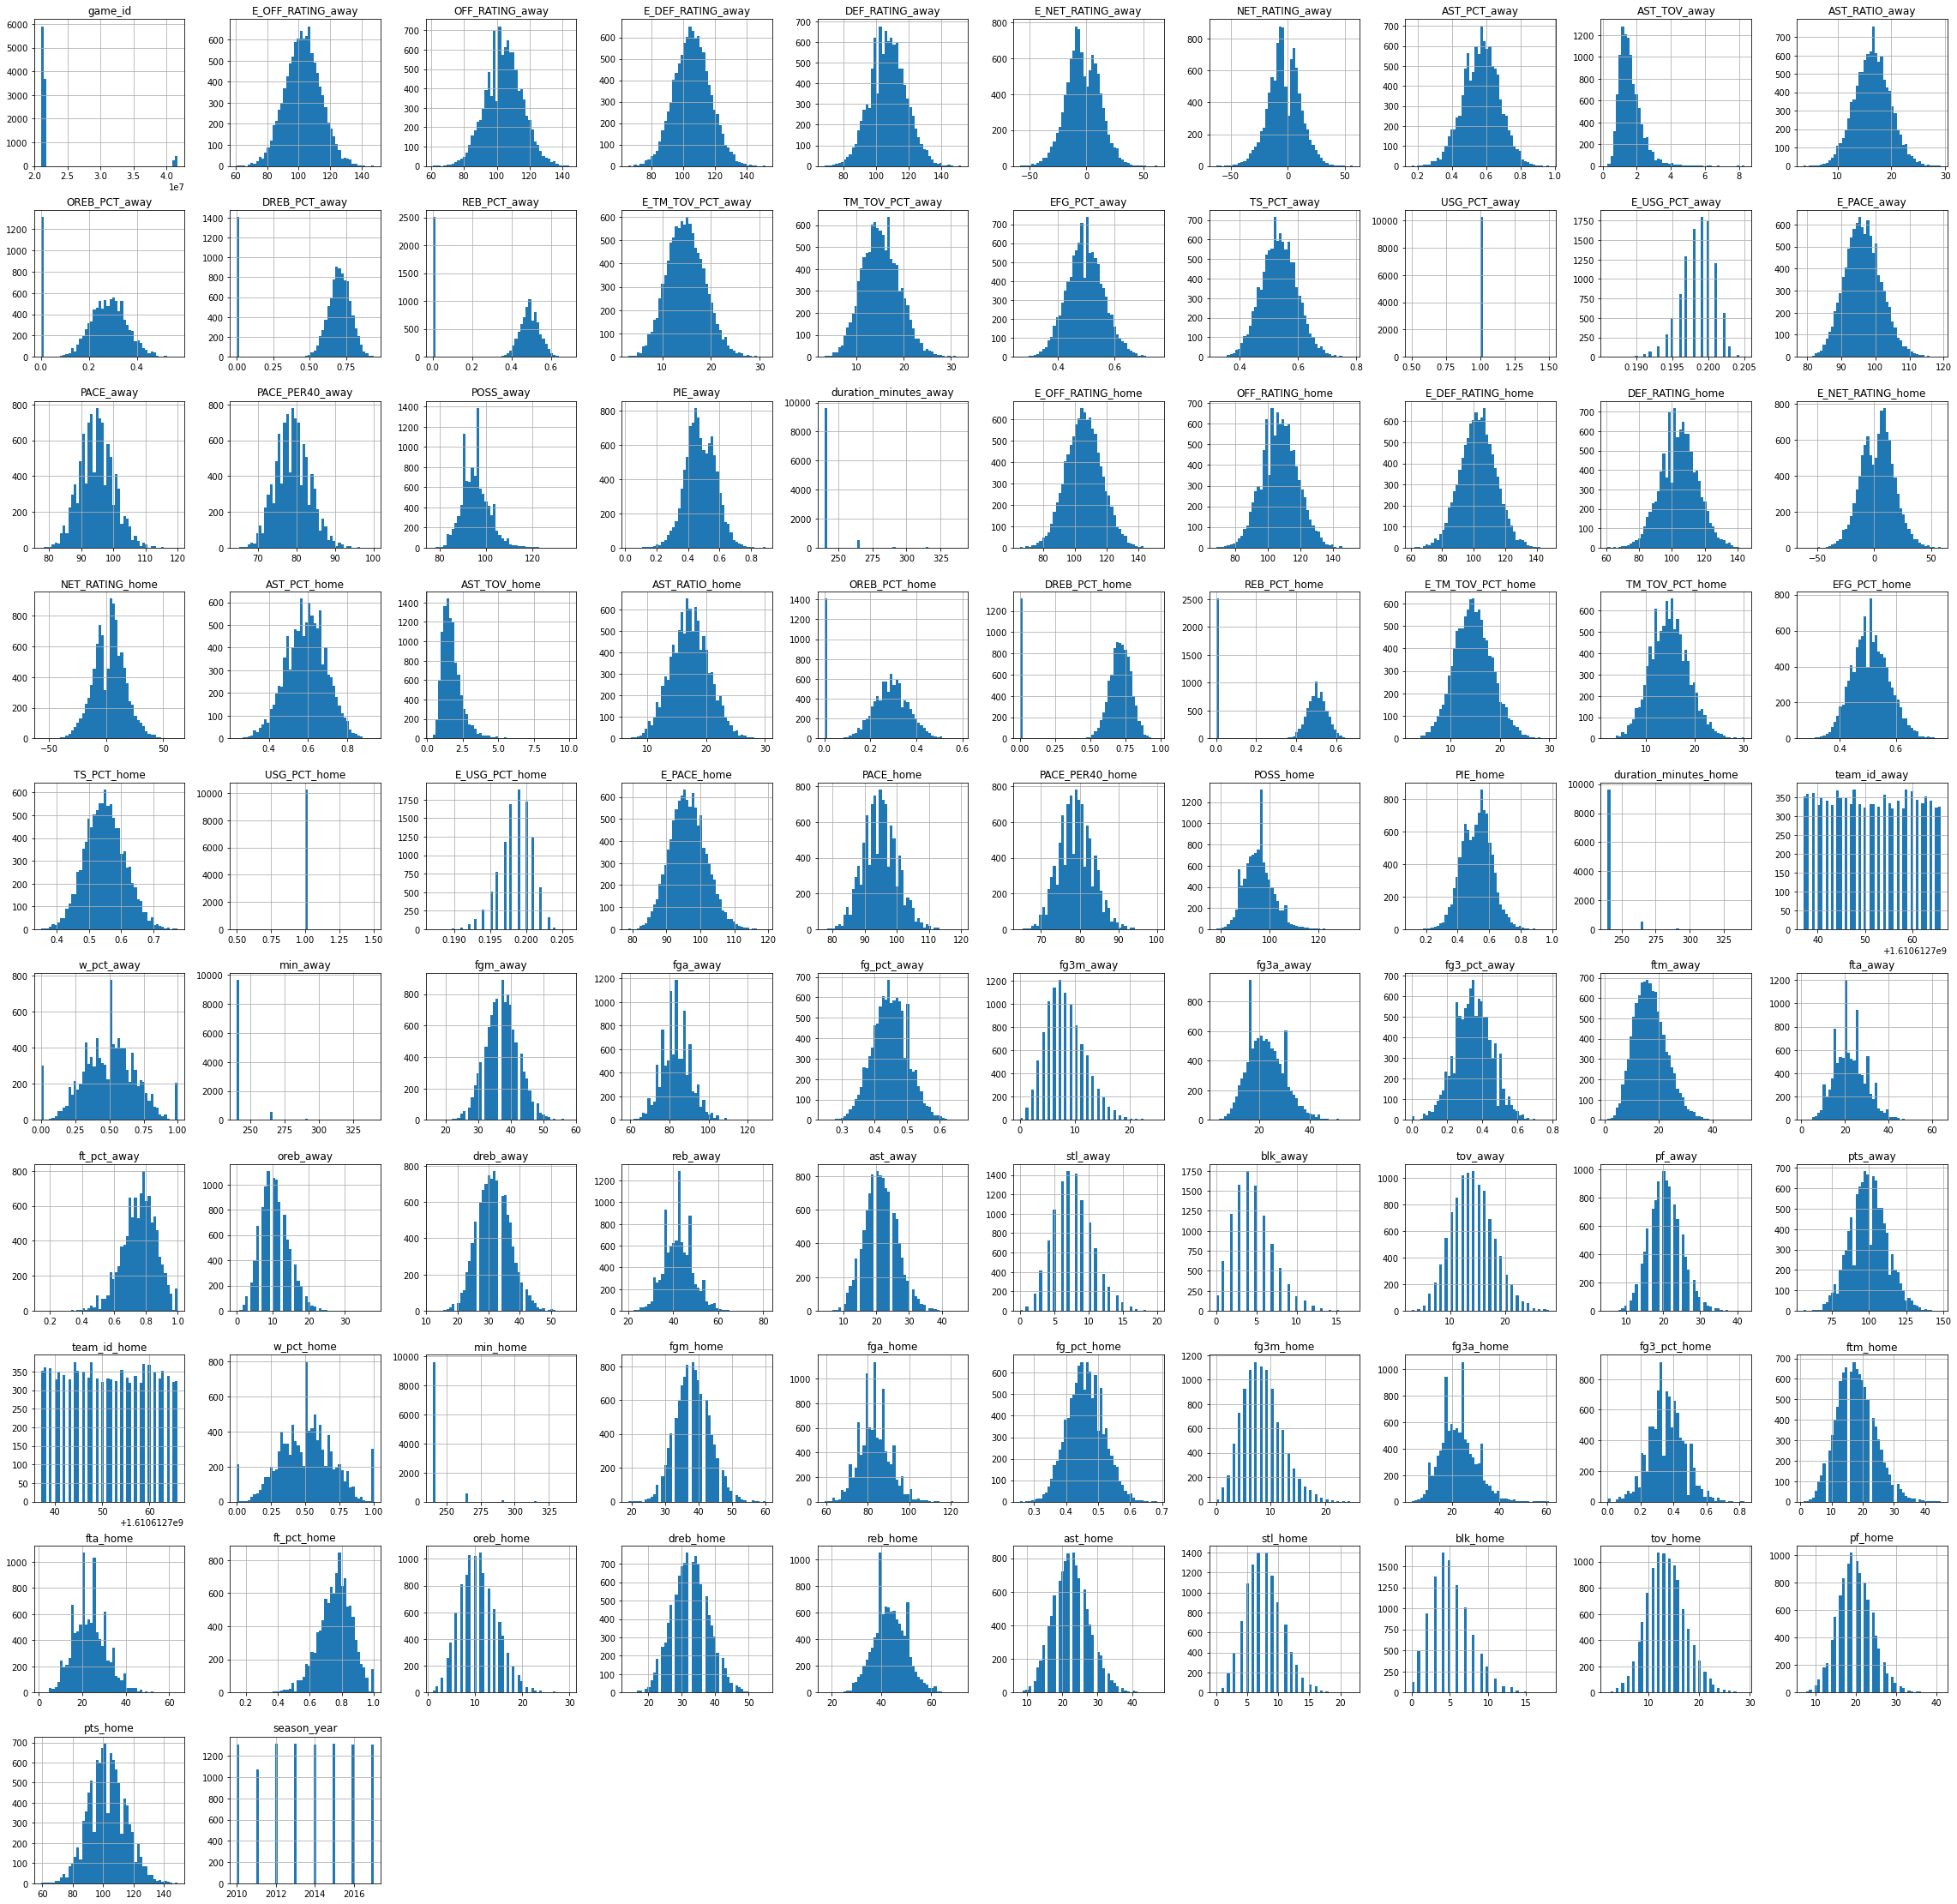

In [9]:
#grid of hist here
hist = df.hist(bins=50,figsize =(40,40))

In [10]:
#select categorical variables only
df_cat = df.select_dtypes(include = 'object').copy()


In [11]:
col_list = list(df_cat.columns)
col_list

['game_date',
 'TEAM_NAME_away',
 'TEAM_ABBREVIATION_away',
 'TEAM_CITY_away',
 'MIN_away',
 'duration_away',
 'TEAM_NAME_home',
 'TEAM_ABBREVIATION_home',
 'TEAM_CITY_home',
 'MIN_home',
 'duration_home',
 'wl_away',
 'wl_home',
 'season_type',
 'season']

In [12]:
col_list_len = len(col_list)
i = 0

2013-04-17    15
2016-11-25    15
2011-04-13    15
2014-04-16    15
2017-02-15    14
              ..
2012-06-17     1
2018-05-15     1
2013-05-22     1
2013-05-30     1
2011-05-19     1
Name: game_date, Length: 1618, dtype: int64


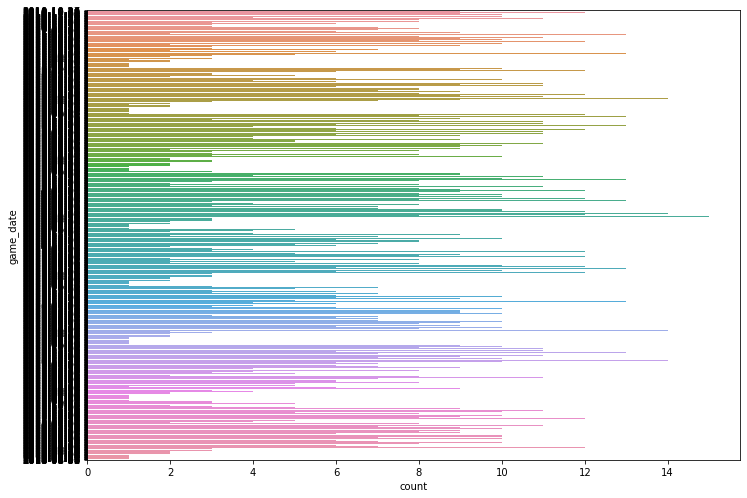

In [13]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

Spurs            371
Heat             370
Warriors         368
Thunder          367
Cavaliers        362
Celtics          359
Pacers           356
Hawks            352
Grizzlies        352
Rockets          349
Bulls            348
Clippers         348
Raptors          344
Mavericks        342
Trail Blazers    342
Wizards          341
76ers            335
Jazz             334
Nets             333
Lakers           333
Bucks            332
Knicks           331
Nuggets          330
Magic            326
Timberwolves     323
Pistons          322
Kings            320
Suns             320
Hornets          286
Pelicans         212
Bobcats          158
Name: TEAM_NAME_away, dtype: int64


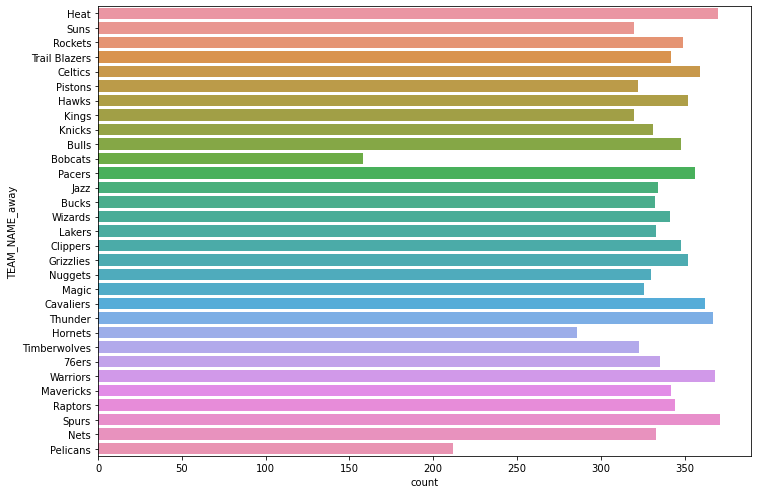

In [14]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

SAS    371
MIA    370
GSW    368
OKC    367
CLE    362
BOS    359
IND    356
MEM    352
ATL    352
HOU    349
LAC    348
CHI    348
TOR    344
DAL    342
POR    342
WAS    341
PHI    335
UTA    334
LAL    333
MIL    332
NYK    331
DEN    330
ORL    326
CHA    326
MIN    323
DET    322
SAC    320
PHX    320
BKN    259
NOP    212
NOH    118
NJN     74
Name: TEAM_ABBREVIATION_away, dtype: int64


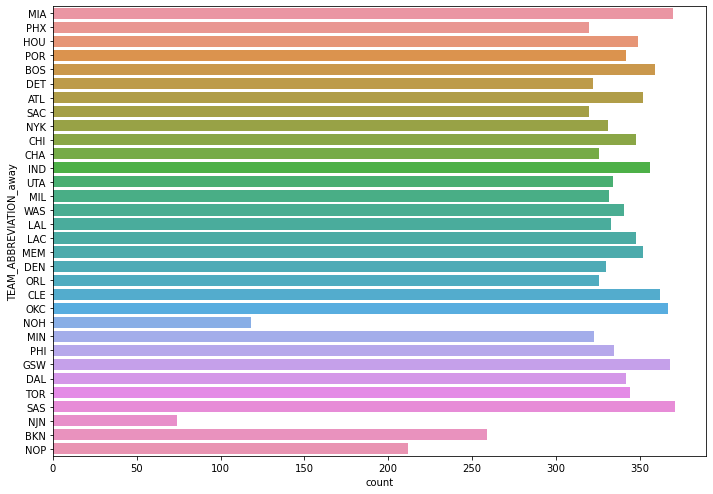

In [15]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

Los Angeles      681
San Antonio      371
Miami            370
Golden State     368
Oklahoma City    367
Cleveland        362
Boston           359
Indiana          356
Memphis          352
Atlanta          352
Houston          349
Chicago          348
Toronto          344
Portland         342
Dallas           342
Washington       341
Philadelphia     335
Utah             334
Milwaukee        332
New York         331
New Orleans      330
Denver           330
Charlotte        326
Orlando          326
Minnesota        323
Detroit          322
Phoenix          320
Sacramento       320
Brooklyn         259
New Jersey        74
Name: TEAM_CITY_away, dtype: int64


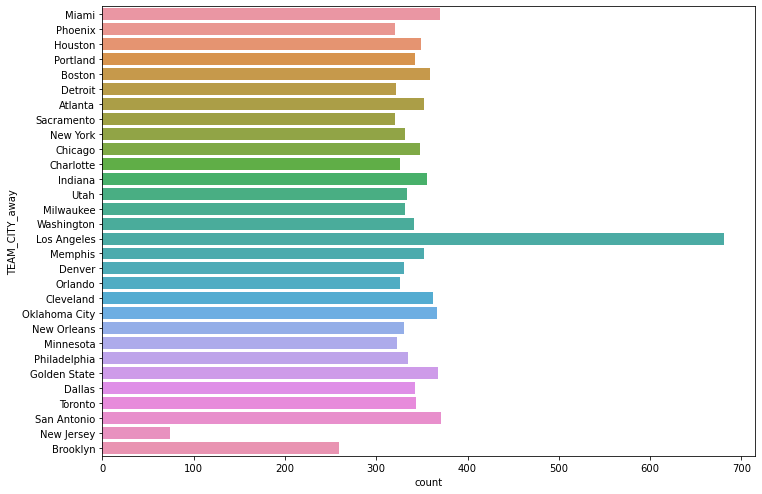

In [16]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

240:00    9633
265:00     541
290:00      71
315:00      17
340:00       3
239:56       1
Name: MIN_away, dtype: int64


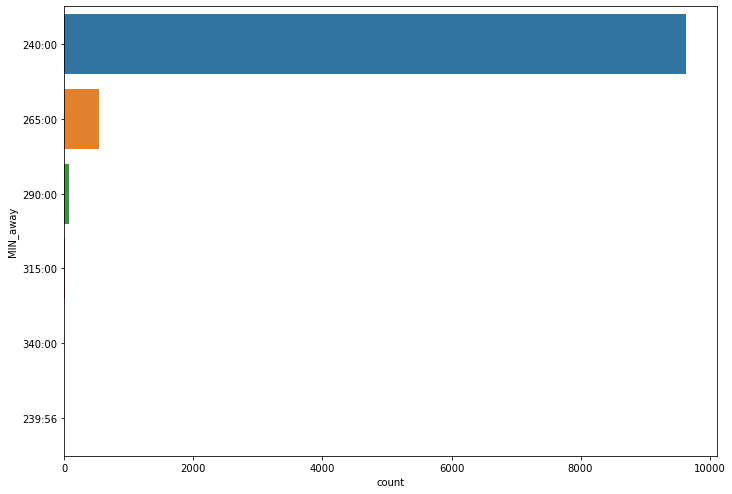

In [17]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

0 days 04:00:00    9633
0 days 04:25:00     541
0 days 04:50:00      71
0 days 05:15:00      17
0 days 05:40:00       3
0 days 03:59:56       1
Name: duration_away, dtype: int64


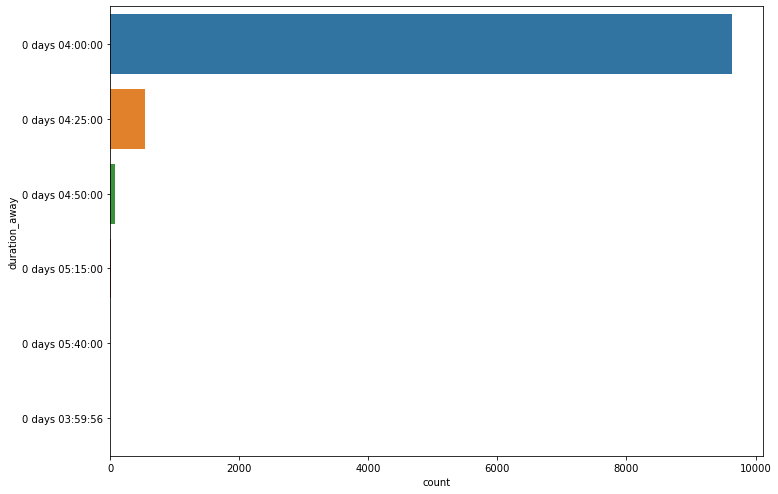

In [18]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

Heat             376
Warriors         374
Spurs            371
Thunder          369
Celtics          362
Cavaliers        359
Pacers           355
Rockets          353
Grizzlies        351
Hawks            351
Bulls            349
Clippers         349
Raptors          347
Mavericks        340
Wizards          339
Trail Blazers    339
Lakers           333
76ers            333
Jazz             332
Nets             332
Bucks            331
Knicks           330
Nuggets          328
Magic            325
Pistons          322
Timberwolves     322
Kings            320
Suns             320
Hornets          285
Pelicans         211
Bobcats          158
Name: TEAM_NAME_home, dtype: int64


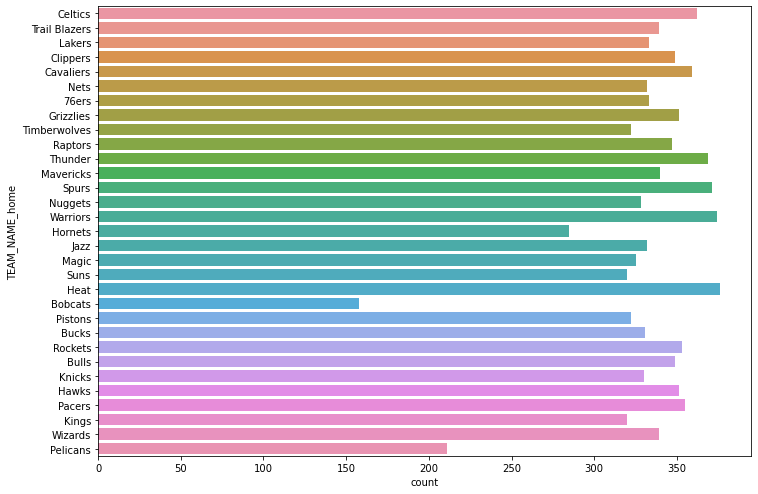

In [19]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

MIA    376
GSW    374
SAS    371
OKC    369
BOS    362
CLE    359
IND    355
HOU    353
ATL    351
MEM    351
CHI    349
LAC    349
TOR    347
DAL    340
WAS    339
POR    339
PHI    333
LAL    333
UTA    332
MIL    331
NYK    330
DEN    328
CHA    325
ORL    325
DET    322
MIN    322
SAC    320
PHX    320
BKN    258
NOP    211
NOH    118
NJN     74
Name: TEAM_ABBREVIATION_home, dtype: int64


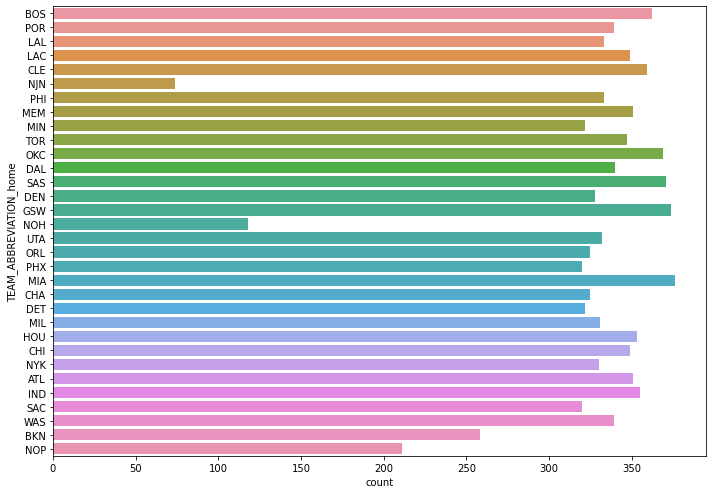

In [20]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

Los Angeles      682
Miami            376
Golden State     374
San Antonio      371
Oklahoma City    369
Boston           362
Cleveland        359
Indiana          355
Houston          353
Memphis          351
Atlanta          351
Chicago          349
Toronto          347
Dallas           340
Portland         339
Washington       339
Philadelphia     333
Utah             332
Milwaukee        331
New York         330
New Orleans      329
Denver           328
Charlotte        325
Orlando          325
Minnesota        322
Detroit          322
Phoenix          320
Sacramento       320
Brooklyn         258
New Jersey        74
Name: TEAM_CITY_home, dtype: int64


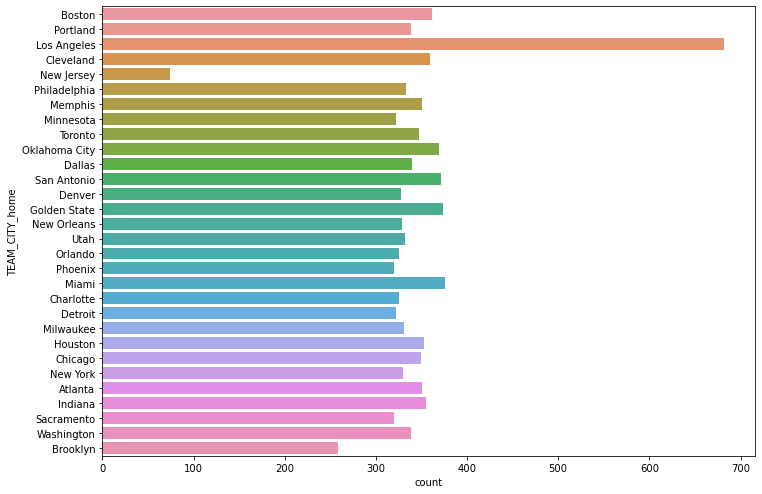

In [21]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

240:00    9633
265:00     541
290:00      71
315:00      17
340:00       3
239:56       1
Name: MIN_home, dtype: int64


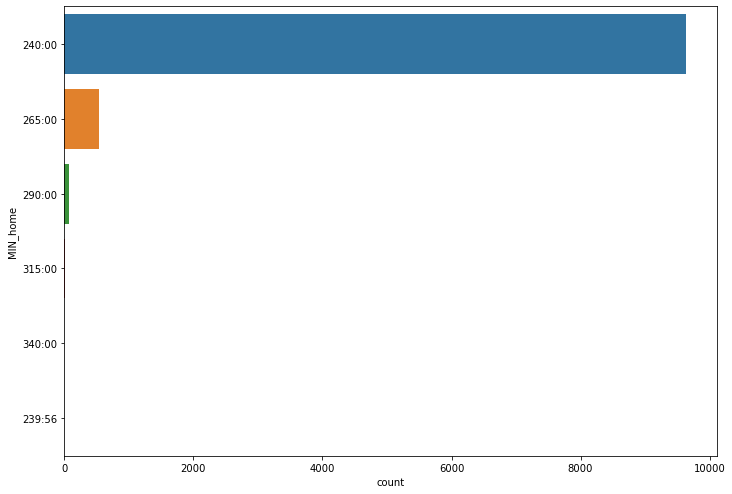

In [22]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

0 days 04:00:00    9633
0 days 04:25:00     541
0 days 04:50:00      71
0 days 05:15:00      17
0 days 05:40:00       3
0 days 03:59:56       1
Name: duration_home, dtype: int64


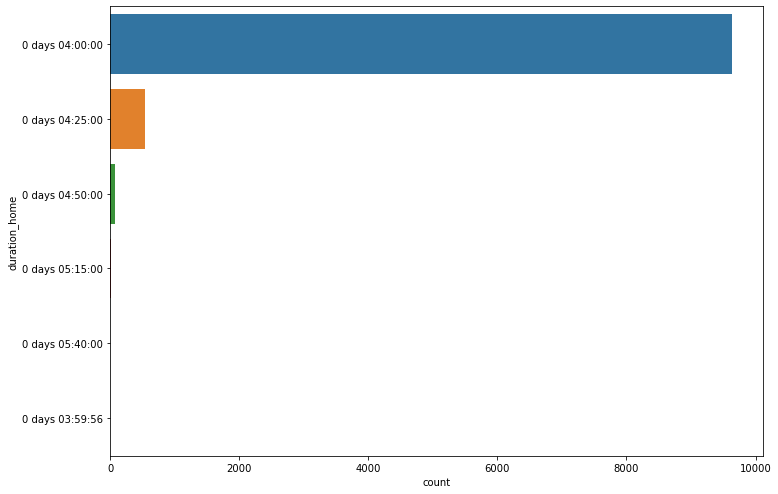

In [23]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

L    6074
W    4192
Name: wl_away, dtype: int64


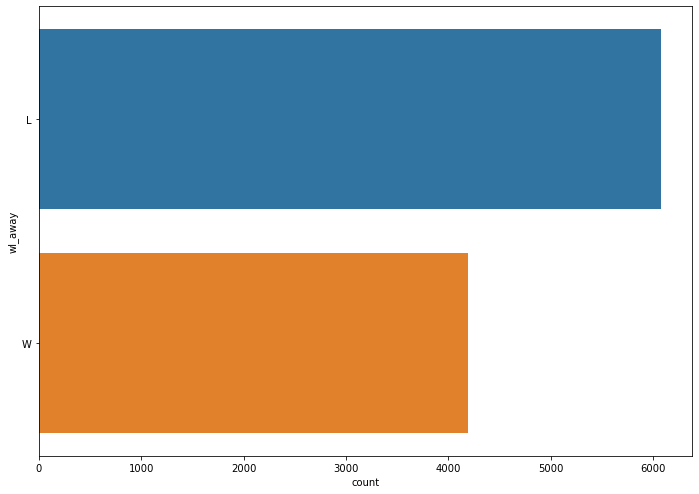

In [24]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

W    6074
L    4192
Name: wl_home, dtype: int64


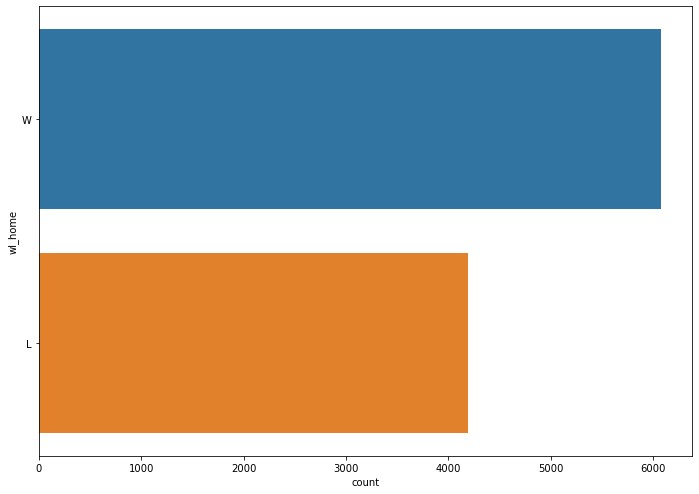

In [25]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

Regular Season    9599
Playoffs           667
Name: season_type, dtype: int64


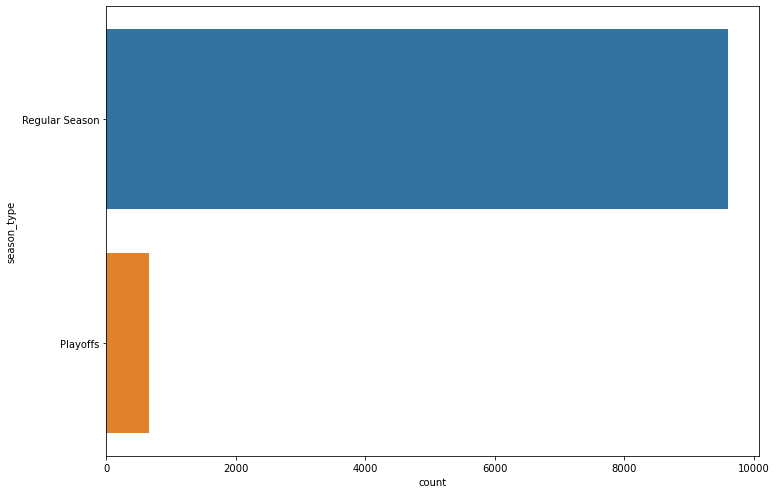

In [26]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

2013-14    1319
2015-16    1316
2012-13    1314
2017-18    1312
2010-11    1311
2014-15    1311
2016-17    1309
2011-12    1074
Name: season, dtype: int64


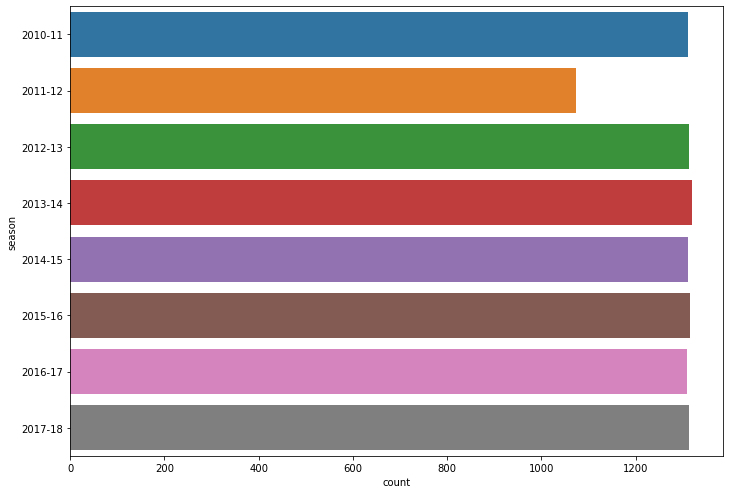

In [27]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variable
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

In [28]:
if (i < col_list_len):
    #get counts of each variable value
    print(df_cat[col_list[i]].value_counts())
    #count plot for one variablen
    a4_dims = (11.7, 8.27)
    fig, ax = plt.subplots(figsize=a4_dims)
    sns.countplot(data = df_cat, y = col_list[i], ax = ax)
    i = i + 1

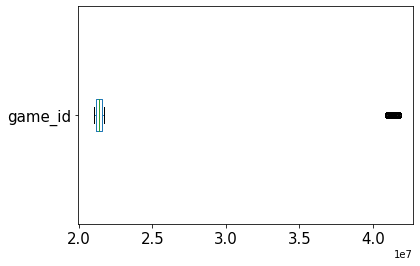

In [29]:
#create a boxplot for every column in df
boxplot = df.iloc[:, 0:1].boxplot(grid=False, vert=False,fontsize=15)

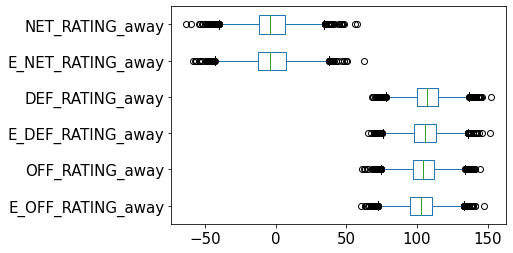

In [30]:
#create a boxplot for every column in df
boxplot = df.iloc[:, 1:18].boxplot(grid=False, vert=False,fontsize=15)

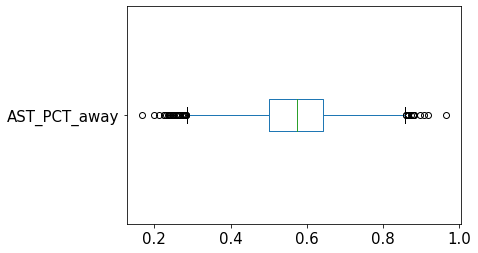

In [31]:
#create a boxplot for every column in df
boxplot = df.iloc[:, 18:19].boxplot(grid=False, vert=False,fontsize=15)

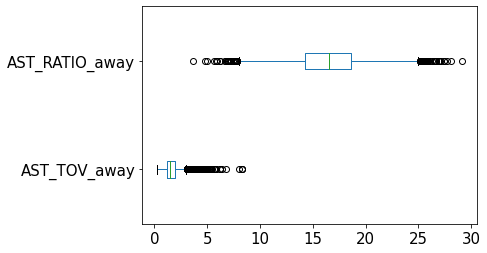

In [32]:
#create a boxplot for every column in df
boxplot = df.iloc[:, 19:21].boxplot(grid=False, vert=False,fontsize=15)

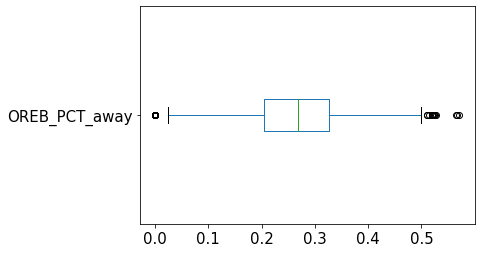

In [33]:
#create a boxplot for every column in df
boxplot = df.iloc[:, 21:22].boxplot(grid=False, vert=False,fontsize=15)

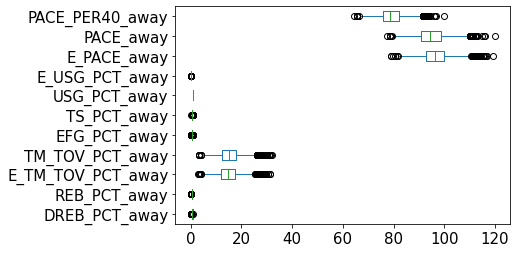

In [34]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 22:33].boxplot(grid=False, vert=False,fontsize=15)

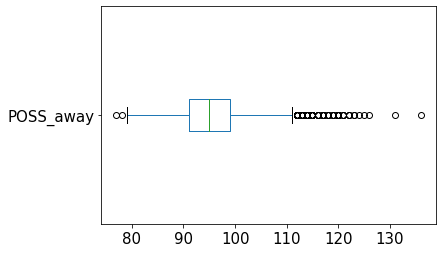

In [35]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 33:34].boxplot(grid=False, vert=False,fontsize=15)

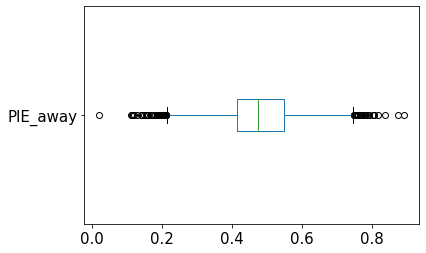

In [36]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 34:35].boxplot(grid=False, vert=False,fontsize=15)

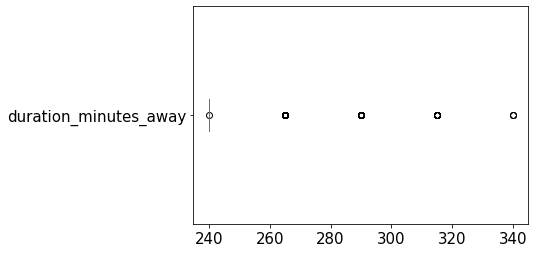

In [37]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 35:36].boxplot(grid=False, vert=False,fontsize=15)

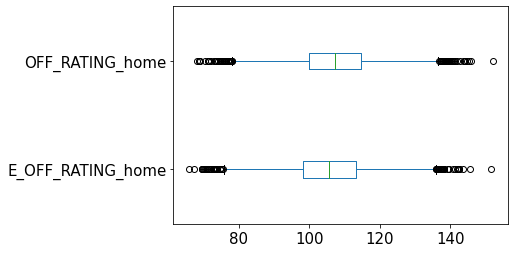

In [38]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 36:38].boxplot(grid=False, vert=False,fontsize=15)

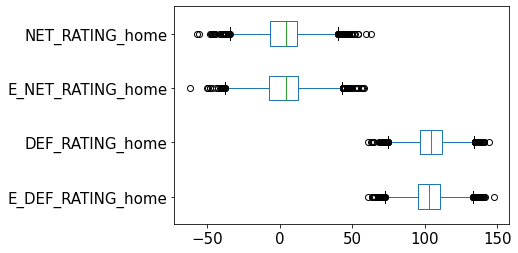

In [39]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 38:42].boxplot(grid=False, vert=False,fontsize=15)

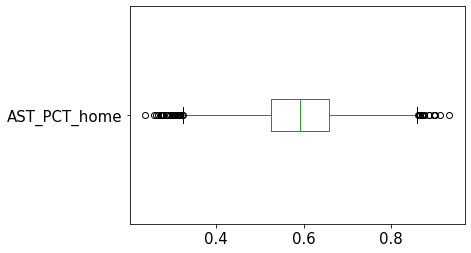

In [40]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 42:43].boxplot(grid=False, vert=False,fontsize=15)

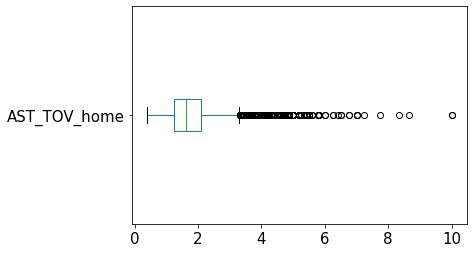

In [41]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 43:44].boxplot(grid=False, vert=False,fontsize=15)

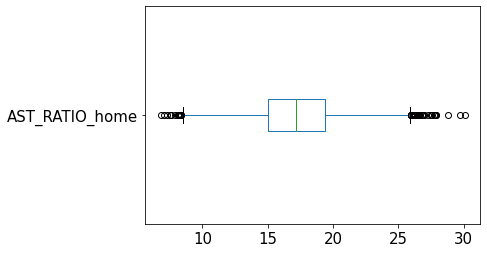

In [42]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 44:45].boxplot(grid=False, vert=False,fontsize=15)

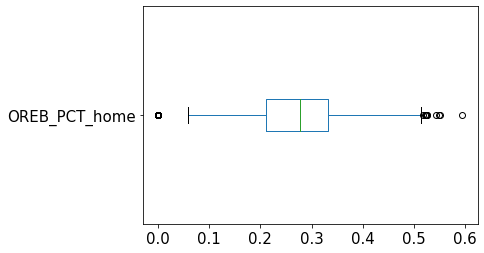

In [43]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 45:46].boxplot(grid=False, vert=False,fontsize=15)

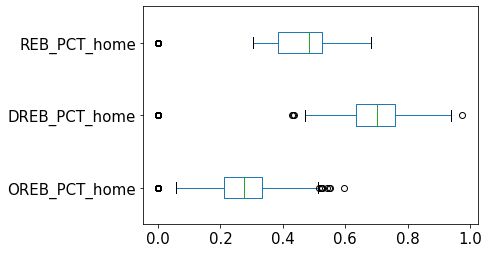

In [44]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 45:48].boxplot(grid=False, vert=False,fontsize=15)

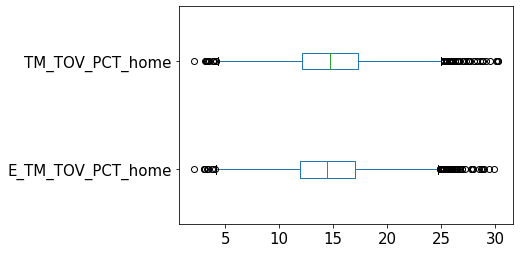

In [45]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 48:50].boxplot(grid=False, vert=False,fontsize=15)

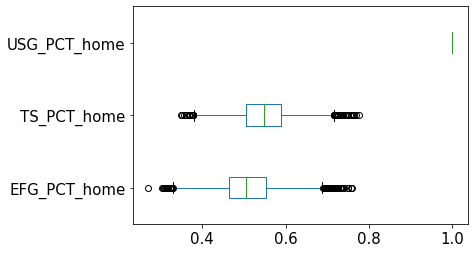

In [46]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 50:53].boxplot(grid=False, vert=False,fontsize=15)

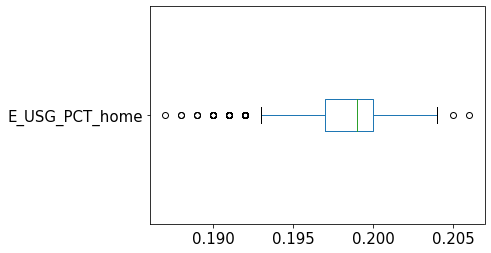

In [47]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 53:54].boxplot(grid=False, vert=False,fontsize=15)

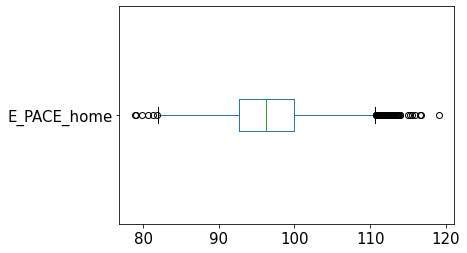

In [48]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 54:55].boxplot(grid=False, vert=False,fontsize=15)

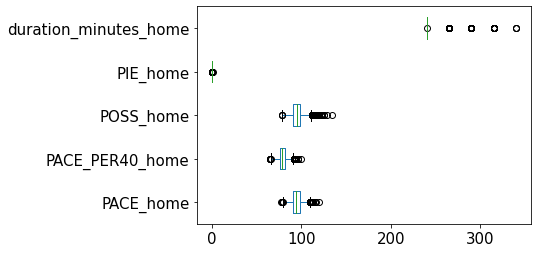

In [49]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 55:60].boxplot(grid=False, vert=False,fontsize=15)

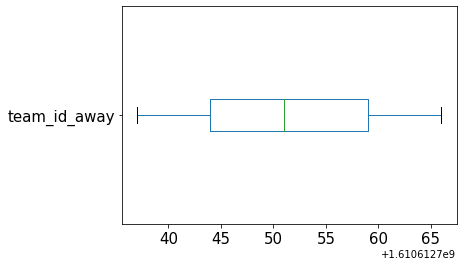

In [50]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 60:61].boxplot(grid=False, vert=False,fontsize=15)

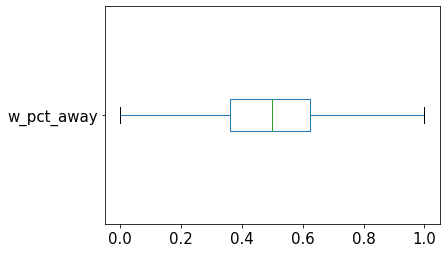

In [51]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 61:63].boxplot(grid=False, vert=False,fontsize=15)

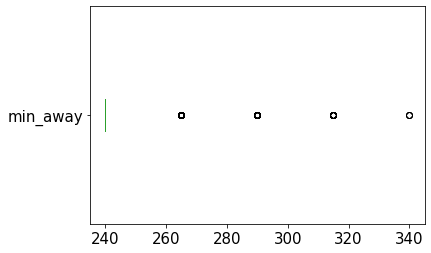

In [52]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 63:64].boxplot(grid=False, vert=False,fontsize=15)

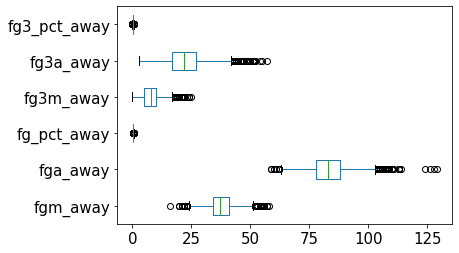

In [53]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 64:70].boxplot(grid=False, vert=False,fontsize=15)

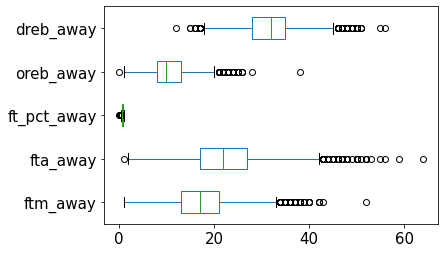

In [54]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 70:75].boxplot(grid=False, vert=False,fontsize=15)

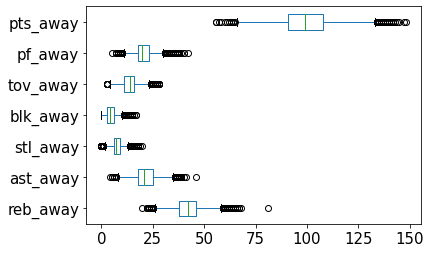

In [55]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 75:83].boxplot(grid=False, vert=False,fontsize=15)

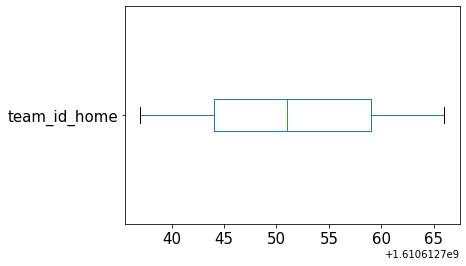

In [56]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 83:84].boxplot(grid=False, vert=False,fontsize=15)

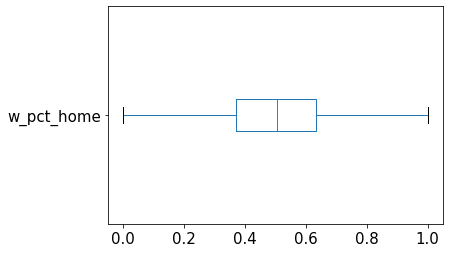

In [57]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 84:85].boxplot(grid=False, vert=False,fontsize=15)

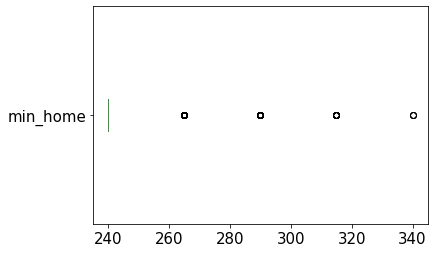

In [58]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 85:86].boxplot(grid=False, vert=False,fontsize=15)

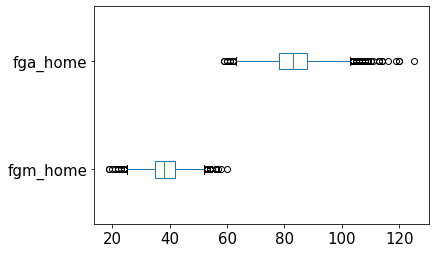

In [59]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 86:88].boxplot(grid=False, vert=False,fontsize=15)

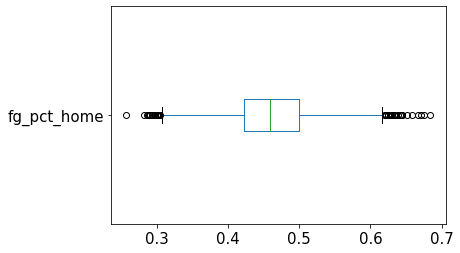

In [60]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 88:89].boxplot(grid=False, vert=False,fontsize=15)

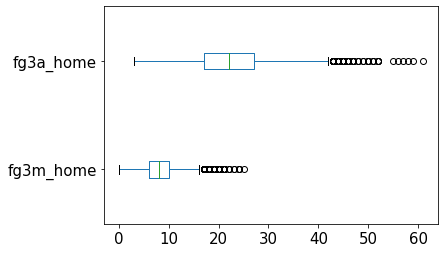

In [61]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 89:91].boxplot(grid=False, vert=False,fontsize=15)

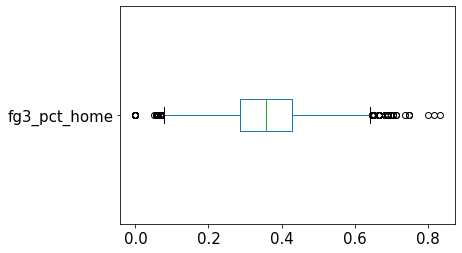

In [62]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 91:92].boxplot(grid=False, vert=False,fontsize=15)

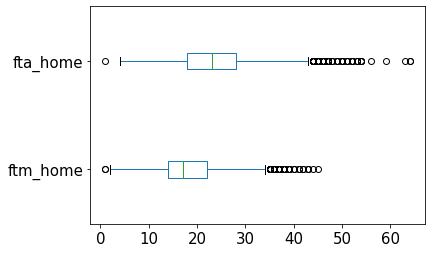

In [63]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 92:94].boxplot(grid=False, vert=False,fontsize=15)

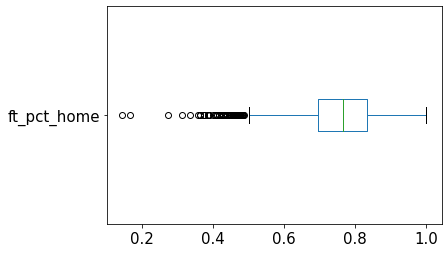

In [64]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 94:95].boxplot(grid=False, vert=False,fontsize=15)

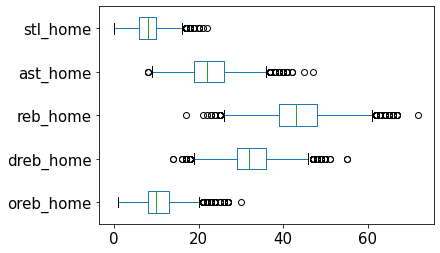

In [65]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 95:100].boxplot(grid=False, vert=False,fontsize=15)

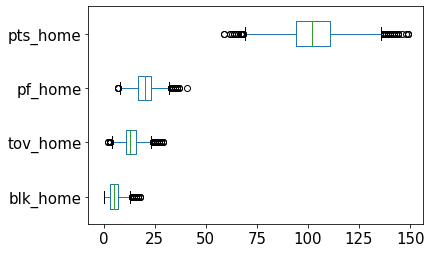

In [66]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 100:106].boxplot(grid=False, vert=False,fontsize=15)

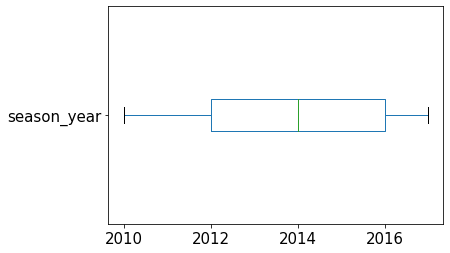

In [67]:
#create a boxplot for every column in df1
boxplot = df.iloc[:, 106:107].boxplot(grid=False, vert=False,fontsize=15)

In [68]:
#########################################################
#get numeric data: df_numerics

#get numeric columns: col_names_numeric

#boxplot df_numerics

In [69]:
df_numerics = df.select_dtypes('number')
p(df_numerics)

(10266, 92)


,game_id,E_OFF_RATING_away,OFF_RATING_away,E_DEF_RATING_away,DEF_RATING_away,E_NET_RATING_away,NET_RATING_away,AST_PCT_away,AST_TOV_away,AST_RATIO_away,OREB_PCT_away,DREB_PCT_away,REB_PCT_away,E_TM_TOV_PCT_away,TM_TOV_PCT_away,EFG_PCT_away,TS_PCT_away,USG_PCT_away,E_USG_PCT_away,E_PACE_away,PACE_away,PACE_PER40_away,POSS_away,PIE_away,duration_minutes_away,E_OFF_RATING_home,OFF_RATING_home,E_DEF_RATING_home,DEF_RATING_home,E_NET_RATING_home,NET_RATING_home,AST_PCT_home,AST_TOV_home,AST_RATIO_home,OREB_PCT_home,DREB_PCT_home,REB_PCT_home,E_TM_TOV_PCT_home,TM_TOV_PCT_home,EFG_PCT_home,TS_PCT_home,USG_PCT_home,E_USG_PCT_home,E_PACE_home,PACE_home,PACE_PER40_home,POSS_home,PIE_home,duration_minutes_home,team_id_away,w_pct_away,min_away,fgm_away,fga_away,fg_pct_away,fg3m_away,fg3a_away,fg3_pct_away,ftm_away,fta_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,team_id_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year
0,21000001,87.9,87.9,95.7,95.7,-7.7,-7.7,0.556,0.88,12.8,0.250,0.732,0.472,18.681,18.7,0.419,0.471,1.0,0.200,91.50,91.50,76.25,91,0.401,240.0,95.7,95.7,87.9,87.9,7.7,7.7,0.781,1.25,20.0,0.268,0.750,0.528,21.739,21.7,0.522,0.550,1.0,0.196,91.50,91.50,76.25,92,0.599,240.0,1610612748,0.000,240,27,74,0.365,8,20,0.400,18,25,0.720000,11,28,39,15,10,6,17,21,80,1610612738,1.000,240,32,69,0.464,8,16,0.500,16,25,0.640000,8,34,42,25,6,4,18,19,88,2010
1,21000002,98.9,102.2,109.7,117.8,-10.8,-15.6,0.417,0.79,13.0,0.244,0.510,0.391,20.421,21.1,0.547,0.568,1.0,0.196,94.82,90.00,75.00,90,0.375,240.0,109.7,117.8,98.9,102.2,10.8,15.6,0.721,2.07,21.3,0.490,0.756,0.609,15.528,16.7,0.516,0.532,1.0,0.192,94.82,90.00,75.00,90,0.625,240.0,1610612756,0.000,240,36,74,0.486,9,19,0.474,11,16,0.687500,7,23,30,15,3,4,19,19,92,1610612757,1.000,240,43,93,0.462,10,20,0.500,10,15,0.666667,18,30,48,31,11,2,12,22,106,2010
2,21000003,101.6,106.8,105.3,107.7,-3.8,-0.9,0.658,1.19,16.7,0.396,0.695,0.554,19.387,20.4,0.462,0.532,1.0,0.196,107.32,103.50,86.25,103,0.507,240.0,105.3,107.7,101.6,106.8,3.8,0.9,0.525,1.75,14.9,0.305,0.604,0.446,11.287,11.5,0.464,0.517,1.0,0.198,107.32,103.50,86.25,104,0.493,240.0,1610612745,0.000,240,38,91,0.418,8,20,0.400,26,28,0.928571,16,37,53,25,6,7,20,25,110,1610612747,1.000,240,40,96,0.417,9,21,0.429,23,28,0.821429,14,30,44,21,11,4,12,24,112,2010
3,21000016,107.6,108.9,94.4,97.8,13.1,11.1,0.472,1.21,13.2,0.446,0.627,0.533,15.364,15.6,0.455,0.499,1.0,0.198,92.16,90.00,75.00,90,0.551,240.0,94.4,97.8,107.6,108.9,-13.1,-11.1,0.594,1.27,15.1,0.373,0.554,0.467,16.094,16.7,0.437,0.477,1.0,0.200,92.16,90.00,75.00,90,0.449,240.0,1610612757,1.000,240,36,88,0.409,8,20,0.400,18,23,0.782609,21,30,51,17,9,6,12,23,98,1610612746,0.000,240,32,79,0.405,5,18,0.278,19,30,0.633333,14,27,41,19,8,8,15,20,88,2010
4,21000004,92.3,94.6,97.7,103.3,-5.4,-8.7,0.706,1.26,19.3,0.225,0.708,0.489,20.161,20.7,0.493,0.535,1.0,0.198,95.74,92.00,76.67,92,0.477,240.0,97.7,103.3,92.3,94.6,5.4,8.7,0.667,1.60,18.6,0.292,0.775,0.511,15.426,16.3,0.481,0.526,1.0,0.196,95.74,92.00,76.67,92,0.523,240.0,1610612738,0.500,240,34,72,0.472,3,12,0.250,16,21,0.761905,6,32,38,24,8,1,19,24,87,1610612739,1.000,240,36,81,0.444,6,20,0.300,17,21,0.809524,8,29,37,24,5,4,14,20,95,2010
10261,41700317,109.6,111.0,97.2,101.1,12.4,9.9,0.641,1.47,19.5,0.341,0.633,0.510,18.446,18.7,0.588,0.586,1.0,0.200,93.42,91.00,75.83,91,0.568,240.0,97.2,101.1,109.6,111.0,-12.4,-9.9,0.472,1.42,13.2,0.367,0.659,0.490,12.674,13.2,0.439,0.461,1.0,0.201,93.42,91.00,75.83,91,0.432,240.0,1610612744,0.571,240,39,80,0.488,16,39,0.410,7,14,0.500000,11,31,42,25,9,7,16,22,101,1610612745,0.429,240,36,90,0.400,7,44,0.159,13,22,0.590909,17,27,44,17,13,3,12,17,92,2017
10262,41700401,112.1,112.9,120.6,125.3,-8.5,-12.4,0.409,1.50,13.0,0.404,0.822,0.588,11.802,11.9,0.495,0.524,1.0,0.197,92.59,90.57,75.47,101,0.406,26

In [70]:
col_names_numeric = list(df_numerics.columns)
col_names_numeric

['game_id',
 'E_OFF_RATING_away',
 'OFF_RATING_away',
 'E_DEF_RATING_away',
 'DEF_RATING_away',
 'E_NET_RATING_away',
 'NET_RATING_away',
 'AST_PCT_away',
 'AST_TOV_away',
 'AST_RATIO_away',
 'OREB_PCT_away',
 'DREB_PCT_away',
 'REB_PCT_away',
 'E_TM_TOV_PCT_away',
 'TM_TOV_PCT_away',
 'EFG_PCT_away',
 'TS_PCT_away',
 'USG_PCT_away',
 'E_USG_PCT_away',
 'E_PACE_away',
 'PACE_away',
 'PACE_PER40_away',
 'POSS_away',
 'PIE_away',
 'duration_minutes_away',
 'E_OFF_RATING_home',
 'OFF_RATING_home',
 'E_DEF_RATING_home',
 'DEF_RATING_home',
 'E_NET_RATING_home',
 'NET_RATING_home',
 'AST_PCT_home',
 'AST_TOV_home',
 'AST_RATIO_home',
 'OREB_PCT_home',
 'DREB_PCT_home',
 'REB_PCT_home',
 'E_TM_TOV_PCT_home',
 'TM_TOV_PCT_home',
 'EFG_PCT_home',
 'TS_PCT_home',
 'USG_PCT_home',
 'E_USG_PCT_home',
 'E_PACE_home',
 'PACE_home',
 'PACE_PER40_home',
 'POSS_home',
 'PIE_home',
 'duration_minutes_home',
 'team_id_away',
 'w_pct_away',
 'min_away',
 'fgm_away',
 'fga_away',
 'fg_pct_away',
 'fg3m_aw

In [121]:
df_numerics.shape

(10266, 92)

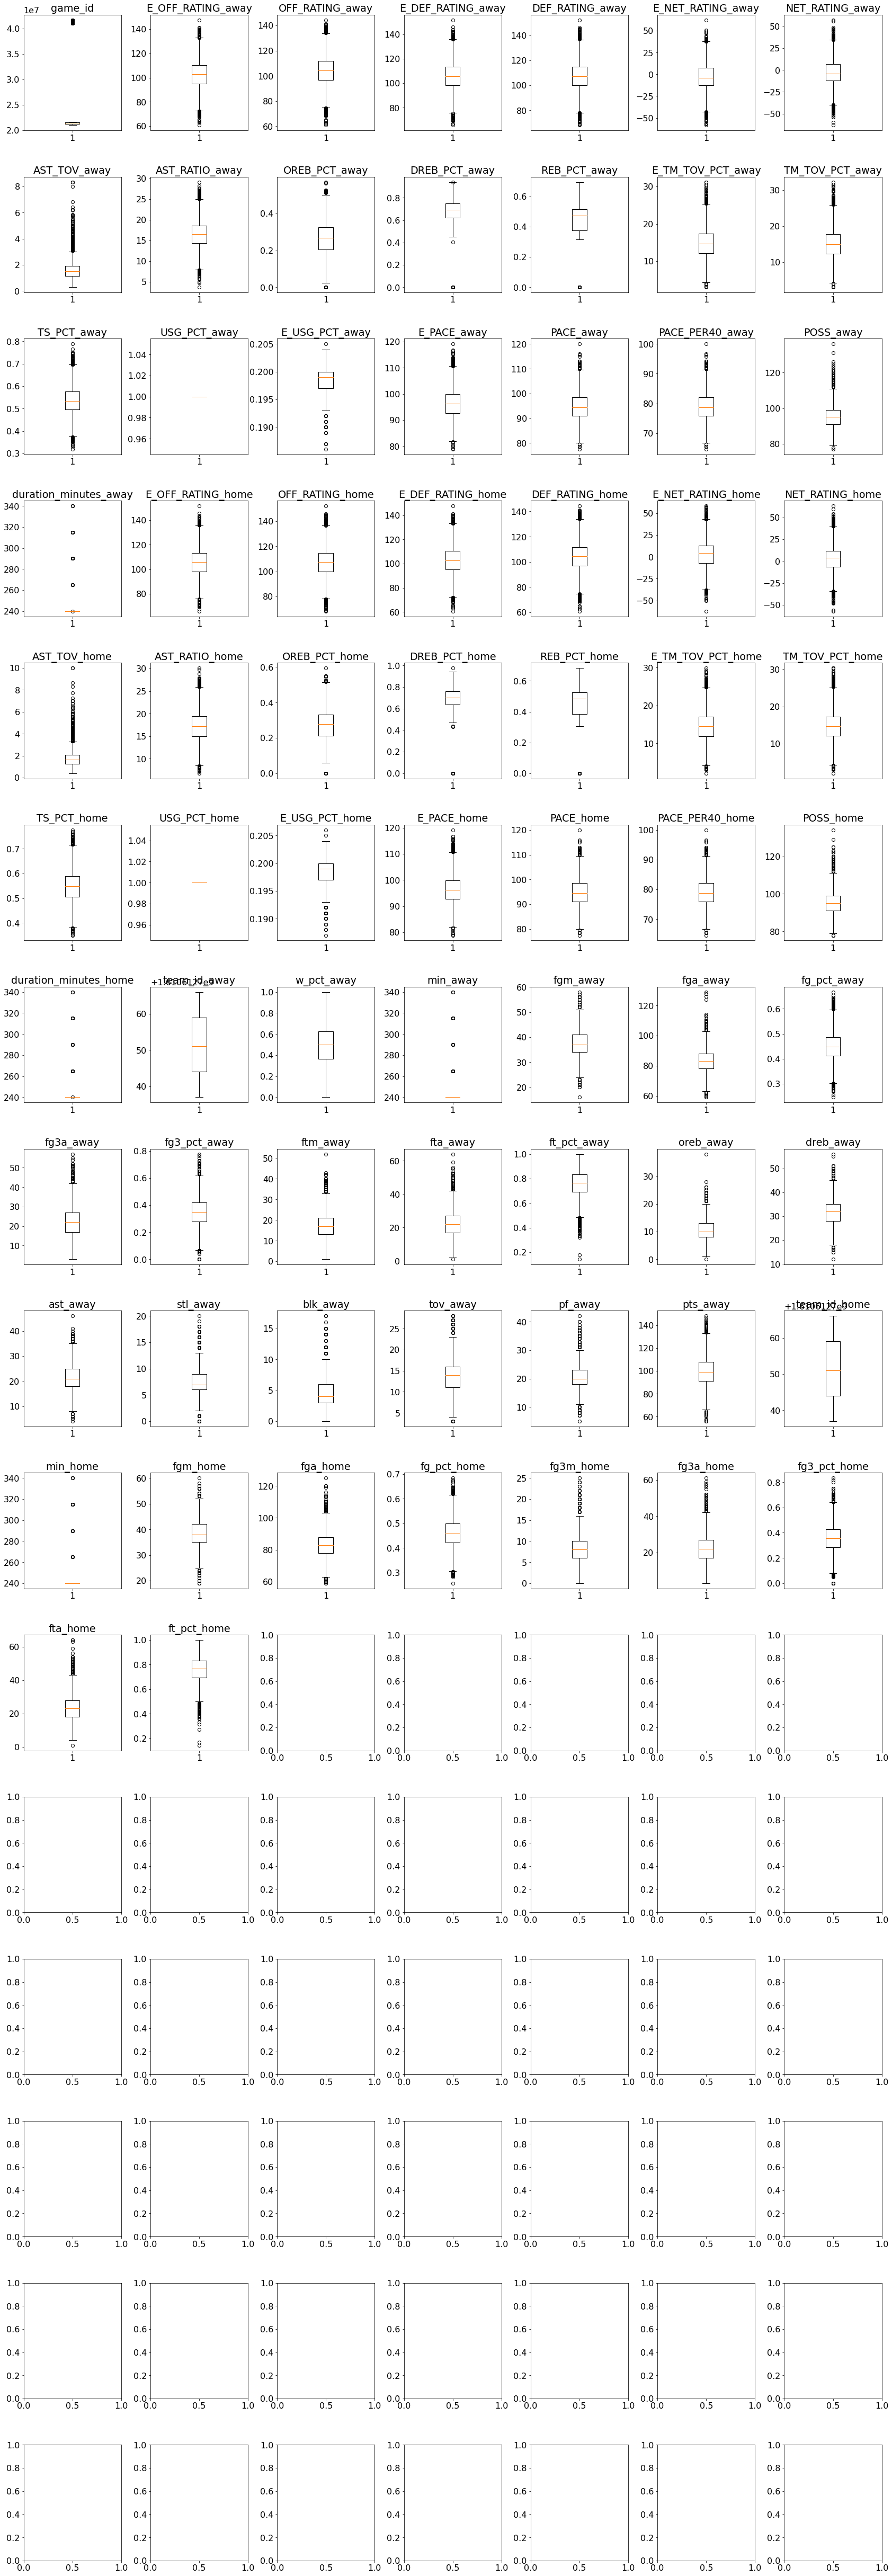

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon


# Fixing random state for reproducibility
np.random.seed(19680801)

plt.rc('font', size=16)
fig, axs = plt.subplots(16, 7,figsize=(5,15))

i = 0
j = 0
k = 0

def increment_me(j, k):
    return (j + 1), (k + 1)

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1

if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    axs[i, j].set_title(col_names_numeric[k])
    j, k = increment_me(j, k)
    
else:
    i = i + 1
    j = 0
    k = k + 1








#
scl = 5
fig.subplots_adjust(left=0.08*5, right=0.98*5, bottom=0.05, top=0.9*5,
                    hspace=0.4, wspace=0.3)



plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

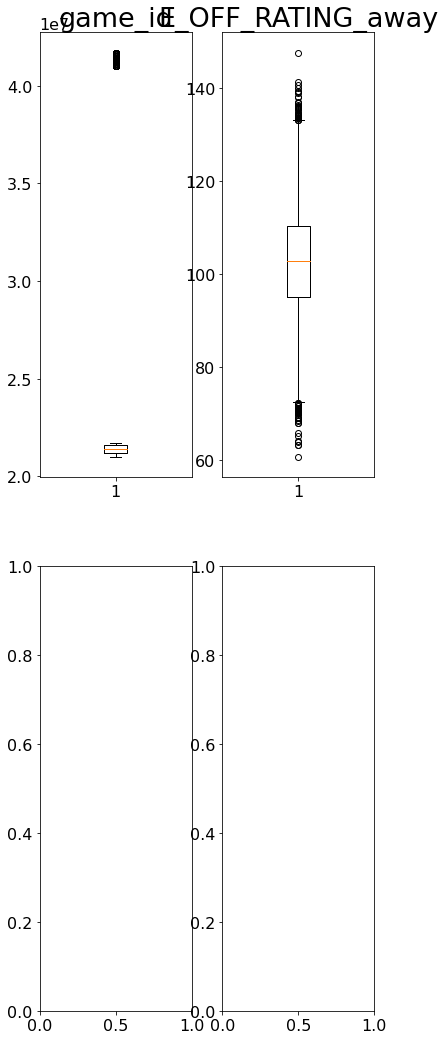

In [114]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon


# Fixing random state for reproducibility
np.random.seed(19680801)


fig, axs = plt.subplots(2, 2,figsize=(6,18))

i = 0
j = 0
k = 0

#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1


#############
if (j < 7):
    axs[i, j].boxplot(df_numerics[col_names_numeric[k]])
    plt.setp(ax.get_xticklabels(), fontsize=40)
    axs[i, j].set_title(col_names_numeric[k], size=27)
    j = j + 1
    k = k + 1
else:
    j = 0
    i = i + 1






    


#
scl = 5
fig.subplots_adjust(left=0.08*5, right=0.98*5, bottom=0.05, top=0.9*5,
                    hspace=0.4, wspace=0.3)



plt.show()

### 3.4.2 State-wide summary data<a id='3.4.2_State-wide_summary_data'></a>

In [74]:
#state_summary = pd.read_csv('data/state_summary.csv')

In [75]:
#state_summary.info()

In [76]:
#state_summary.head()

## 3.5 Explore The Data<a id='3.5_Explore_The_Data'></a>

### 3.5.1 Top States By Order Of Each Of The Summary Statistics<a id='3.5.1_Top_States_By_Order_Of_Each_Of_The_Summary_Statistics'></a>

What does the state-wide picture for your market look like?

In [77]:
#df = state_summary.set_index('state')

In [78]:
p(df)

(10266, 107)


,game_id,game_date,TEAM_NAME_away,TEAM_ABBREVIATION_away,TEAM_CITY_away,MIN_away,duration_away,TEAM_NAME_home,TEAM_ABBREVIATION_home,TEAM_CITY_home,MIN_home,duration_home,E_OFF_RATING_away,OFF_RATING_away,E_DEF_RATING_away,DEF_RATING_away,E_NET_RATING_away,NET_RATING_away,AST_PCT_away,AST_TOV_away,AST_RATIO_away,OREB_PCT_away,DREB_PCT_away,REB_PCT_away,E_TM_TOV_PCT_away,TM_TOV_PCT_away,EFG_PCT_away,TS_PCT_away,USG_PCT_away,E_USG_PCT_away,E_PACE_away,PACE_away,PACE_PER40_away,POSS_away,PIE_away,duration_minutes_away,E_OFF_RATING_home,OFF_RATING_home,E_DEF_RATING_home,DEF_RATING_home,E_NET_RATING_home,NET_RATING_home,AST_PCT_home,AST_TOV_home,AST_RATIO_home,OREB_PCT_home,DREB_PCT_home,REB_PCT_home,E_TM_TOV_PCT_home,TM_TOV_PCT_home,EFG_PCT_home,TS_PCT_home,USG_PCT_home,E_USG_PCT_home,E_PACE_home,PACE_home,PACE_PER40_home,POSS_home,PIE_home,duration_minutes_home,team_id_away,wl_away,w_pct_away,min_away,fgm_away,fga_away,fg_pct_away,fg3m_away,fg3a_away,fg3_pct_away,ftm_away,fta_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,wl_home,team_id_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_type,season,season_year
0,21000001,2010-10-26,Heat,MIA,Miami,240:00,0 days 04:00:00,Celtics,BOS,Boston,240:00,0 days 04:00:00,87.9,87.9,95.7,95.7,-7.7,-7.7,0.556,0.88,12.8,0.250,0.732,0.472,18.681,18.7,0.419,0.471,1.0,0.200,91.50,91.50,76.25,91,0.401,240.0,95.7,95.7,87.9,87.9,7.7,7.7,0.781,1.25,20.0,0.268,0.750,0.528,21.739,21.7,0.522,0.550,1.0,0.196,91.50,91.50,76.25,92,0.599,240.0,1610612748,L,0.000,240,27,74,0.365,8,20,0.400,18,25,0.720000,11,28,39,15,10,6,17,21,80,W,1610612738,1.000,240,32,69,0.464,8,16,0.500,16,25,0.640000,8,34,42,25,6,4,18,19,88,Regular Season,2010-11,2010
1,21000002,2010-10-26,Suns,PHX,Phoenix,240:00,0 days 04:00:00,Trail Blazers,POR,Portland,240:00,0 days 04:00:00,98.9,102.2,109.7,117.8,-10.8,-15.6,0.417,0.79,13.0,0.244,0.510,0.391,20.421,21.1,0.547,0.568,1.0,0.196,94.82,90.00,75.00,90,0.375,240.0,109.7,117.8,98.9,102.2,10.8,15.6,0.721,2.07,21.3,0.490,0.756,0.609,15.528,16.7,0.516,0.532,1.0,0.192,94.82,90.00,75.00,90,0.625,240.0,1610612756,L,0.000,240,36,74,0.486,9,19,0.474,11,16,0.687500,7,23,30,15,3,4,19,19,92,W,1610612757,1.000,240,43,93,0.462,10,20,0.500,10,15,0.666667,18,30,48,31,11,2,12,22,106,Regular Season,2010-11,2010
2,21000003,2010-10-26,Rockets,HOU,Houston,240:00,0 days 04:00:00,Lakers,LAL,Los Angeles,240:00,0 days 04:00:00,101.6,106.8,105.3,107.7,-3.8,-0.9,0.658,1.19,16.7,0.396,0.695,0.554,19.387,20.4,0.462,0.532,1.0,0.196,107.32,103.50,86.25,103,0.507,240.0,105.3,107.7,101.6,106.8,3.8,0.9,0.525,1.75,14.9,0.305,0.604,0.446,11.287,11.5,0.464,0.517,1.0,0.198,107.32,103.50,86.25,104,0.493,240.0,1610612745,L,0.000,240,38,91,0.418,8,20,0.400,26,28,0.928571,16,37,53,25,6,7,20,25,110,W,1610612747,1.000,240,40,96,0.417,9,21,0.429,23,28,0.821429,14,30,44,21,11,4,12,24,112,Regular Season,2010-11,2010
3,21000016,2010-10-27,Trail Blazers,POR,Portland,240:00,0 days 04:00:00,Clippers,LAC,Los Angeles,240:00,0 days 04:00:00,107.6,108.9,94.4,97.8,13.1,11.1,0.472,1.21,13.2,0.446,0.627,0.533,15.364,15.6,0.455,0.499,1.0,0.198,92.16,90.00,75.00,90,0.551,240.0,94.4,97.8,107.6,108.9,-13.1,-11.1,0.594,1.27,15.1,0.373,0.554,0.467,16.094,16.7,0.437,0.477,1.0,0.200,92.16,90.00,75.00,90,0.449,240.0,1610612757,W,1.000,240,36,88,0.409,8,20,0.400,18,23,0.782609,21,30,51,17,9,6,12,23,98,L,1610612746,0.000,240,32,79,0.405,5,18,0.278,19,30,0.633333,14,27,41,19,8,8,15,20,88,Regular Season,2010-11,2010
4,21000004,2010-10-27,Celtics,BOS,Boston,240:00,0 days 04:00:00,Cavaliers,CLE,Cleveland,240:00,0 days 04:00:00,92.3,94.6,97.7,103.3,-5.4,-8.7,0.706,1.26,19.3,0.225,0.708,0.489,20.161,20.7,0.493,0.535,1.0,0.198,95.74,92.00,76.67,92,0.477,240.0,97.7,103.3,92.3,94.6,5.4,8.7,0.667,1.60,18.6,0.292,0.775,0.511,15.426,16.3,0.481,0.526,1.0,0.196,95.7

In [79]:
df.TEAM_CITY_away.value_counts()

Los Angeles      681
San Antonio      371
Miami            370
Golden State     368
Oklahoma City    367
Cleveland        362
Boston           359
Indiana          356
Memphis          352
Atlanta          352
Houston          349
Chicago          348
Toronto          344
Portland         342
Dallas           342
Washington       341
Philadelphia     335
Utah             334
Milwaukee        332
New York         331
New Orleans      330
Denver           330
Charlotte        326
Orlando          326
Minnesota        323
Detroit          322
Phoenix          320
Sacramento       320
Brooklyn         259
New Jersey        74
Name: TEAM_CITY_away, dtype: int64

In [80]:
#biggest totals for each season and the team involved
df_totals = df[['game_id', 'TEAM_NAME_away', 'TEAM_ID_away','TEAM_NAME_home', 'TEAM_ID_home', 'season']]
df_totals['total_pts'] = df.pts_away + df.pts_home
p(df_totals)

KeyError: "['TEAM_ID_away', 'TEAM_ID_home'] not in index"

In [ ]:
#biggest spreads for each season and the teams involved

In [ ]:
#teams with the most number of wins each season



<font color='red'> where are we making standardizations of the features??????<font>

#### 3.5.1.1 Total state area<a id='3.5.1.1_Total_state_area'></a>

In [ ]:
df.state_area_sq_milfes.sort_values(ascending=False).head()

Your home state, Montana, comes in at third largest.

#### 3.5.1.2 Total state population<a id='3.5.1.2_Total_state_population'></a>

In [ ]:
state_summary_newind.state_population.sort_values(ascending=False).head()

California dominates the state population figures despite coming in second behind Alaska in size (by a long way). The resort's state of Montana was in the top five for size, but doesn't figure in the most populous states. Thus your state is less densely populated.

#### 3.5.1.3 Resorts per state<a id='3.5.1.3_Resorts_per_state'></a>

New York comes top in the number of resorts in our market. Is this because of its proximity to wealthy New Yorkers wanting a convenient skiing trip? Or is it simply that its northerly location means there are plenty of good locations for resorts in that state?

#### 3.5.1.4 Total skiable area<a id='3.5.1.4_Total_skiable_area'></a>

In [ ]:
#total points in a season per team

#average number of points per season per team

New York state may have the most resorts, but they don't account for the most skiing area. In fact, New York doesn't even make it into the top five of skiable area. Good old Montana makes it into the top five, though. You may start to think that New York has more, smaller resorts, whereas Montana has fewer, larger resorts. Colorado seems to have a name for skiing; it's in the top five for resorts and in top place for total skiable area.

#### 3.5.1.5 Total night skiing area<a id='3.5.1.5_Total_night_skiing_area'></a>

In [ ]:
#teams with the most points per season

New York dominates the area of skiing available at night. Looking at the top five in general, they are all the more northerly states. Is night skiing in and of itself an appeal to customers, or is a consequence of simply trying to extend the skiing day where days are shorter? Is New York's domination here because it's trying to maximize its appeal to visitors who'd travel a shorter distance for a shorter visit? You'll find the data generates more (good) questions rather than answering them. This is a positive sign! You might ask your executive sponsor or data provider for some additional data about typical length of stays at these resorts, although you might end up with data that is very granular and most likely proprietary to each resort. A useful level of granularity might be "number of day tickets" and "number of weekly passes" sold.

#### 3.5.1.6 Total days open<a id='3.5.1.6_Total_days_open'></a>

In [ ]:
state_summary_newind.state_total_days_open.sort_values(ascending=False).head()

The total days open seem to bear some resemblance to the number of resorts. This is plausible. The season will only be so long, and so the more resorts open through the skiing season, the more total days open we'll see. New Hampshire makes a good effort at making it into the top five, for a small state that didn't make it into the top five of resorts per state. Does its location mean resorts there have a longer season and so stay open longer, despite there being fewer of them?

### 3.5.2 Resort density<a id='3.5.2_Resort_density'></a>

There are big states which are not necessarily the most populous. There are states that host many resorts, but other states host a larger total skiing area. The states with the most total days skiing per season are not necessarily those with the most resorts. And New York State boasts an especially large night skiing area. New York had the most resorts but wasn't in the top five largest states, so the reason for it having the most resorts can't be simply having lots of space for them. New York has the second largest population behind California. Perhaps many resorts have sprung up in New York because of the population size? Does this mean there is a high competition between resorts in New York State, fighting for customers and thus keeping prices down? You're not concerned, per se, with the absolute size or population of a state, but you could be interested in the ratio of resorts serving a given population or a given area.

So, calculate those ratios! Think of them as measures of resort density, and drop the absolute population and state size columns.

In [ ]:
#teams with most number of non-zero minute players

#teams with the most number of players??


In [ ]:
#state_summary

With the removal of the two columns that only spoke to state-specific data, you now have a Dataframe that speaks to the skiing competitive landscape of each state. It has the number of resorts per state, total skiable area, and days of skiing. You've translated the plain state data into something more useful that gives you an idea of the density of resorts relative to the state population and size.

How do the distributions of these two new features look?

In [ ]:
#teams with the highest average team pace per season

In [ ]:
#count for teams with the highest pace per month per season - stacked bar chart

In [ ]:
#count for teams with teh highest offensive rating per month per season - stacked bar chart

In [ ]:
#count for teams with the lowest denfensive rating per month per seaosn - s.b.c

In [ ]:
#count for teams with the highest 3pt# per month per season - s.b.c

In [ ]:
state_summary.resorts_per_100ksq_mile.hist(bins=30)
plt.xlabel('Number of resorts per 100k square miles')
plt.ylabel('count');

So they have quite some long tails on them, but there's definitely some structure there.

#### 3.5.2.1 Top states by resort density<a id='3.5.2.1_Top_states_by_resort_density'></a>

In [ ]:
#top teams by pace per season

In [ ]:
#top teams by offensive rating per season

In [ ]:
#top teams by densive rating per season

In [ ]:
#top team by 3pt% per season

In [ ]:
state_summary.set_index('state').resorts_per_100kcapita.sort_values(ascending=False).head()

In [ ]:
state_summary.set_index('state').resorts_per_100ksq_mile.sort_values(ascending=False).head()

Vermont seems particularly high in terms of resorts per capita, and both New Hampshire and Vermont top the chart for resorts per area. New York doesn't appear in either!

### 3.5.3 Visualizing High Dimensional Data<a id='3.5.3_Visualizing_High_Dimensional_Data'></a>

You may be starting to feel there's a bit of a problem here, or at least a challenge. You've constructed some potentially useful and business relevant features, derived from summary statistics, for each of the states you're concerned with. You've explored many of these features in turn and found various trends. Some states are higher in some but not in others. Some features will also be more correlated with one another than others.

One way to disentangle this interconnected web of relationships is via [principle components analysis](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA) (PCA). This technique will find linear combinations of the original features that are uncorrelated with one another and order them by the amount of variance they explain. You can use these derived features to visualize the data in a lower dimension (e.g. 2 down from 7) and know how much variance the representation explains. You can also explore how the original features contribute to these derived features.

The basic steps in this process are:

1. scale the data (important here because our features are heterogenous)
2. fit the PCA transformation (learn the transformation from the data)
3. apply the transformation to the data to create the derived features
4. (optionally) use the derived features to look for patterns in the data and explore the coefficients

#### 3.5.3.1 Scale the data<a id='3.5.3.1_Scale_the_data'></a>

You only want numeric data here, although you don't want to lose track of the state labels, so it's convenient to set the state as the index.

In [ ]:
#Code task 1#
#Create a new dataframe, `state_summary_scale` from `state_summary` whilst setting the index to 'state'
state_summary_scale = state_summary.set_index('state')
#Save the state labels (using the index attribute of `state_summary_scale`) into the variable 'state_summary_index'
state_summary_index = state_summary_scale.index
#Save the column names (using the `columns` attribute) of `state_summary_scale` into the variable 'state_summary_columns'
state_summary_columns = state_summary_scale.columns
state_summary_scale.head()

In [ ]:
state_summary_scale

In [ ]:
state_summary_scale.iloc[20]

The above shows what we expect: the columns we want are all numeric and the state has been moved to the index. Although, it's not necessary to step through the sequence so laboriously, it is often good practice even for experienced professionals. It's easy to make a mistake or forget a step, or the data may have been holding out a surprise! Stepping through like this helps  validate both your work and the data!

Now use `scale()` to scale the data.

In [ ]:
#temporarily set_index
col_list = list(df.select_dtypes(exclude=np.number).columns)
col_list

In [ ]:
col_list = col_list + ['team_id_home', 'team_id_away', 'game_id']
col_list

In [ ]:
df

In [ ]:
df_scale = scale(df.select_dtypes(include=np.number).drop(columns=['team_id_home', 'team_id_away', 'game_id']))
df_scale

Note, `scale()` returns an ndarray, so you lose the column names. Because you want to visualise scaled data, you already copied the column names. Now you can construct a dataframe from the ndarray here and reintroduce the column names.

In [ ]:
#Code task 2#
#Create a new dataframe from `state_summary_scale` using the column names we saved in `state_summary_columns`
df_scaled = pd.DataFrame(df_scale, columns=df.select_dtypes(include=np.number).drop(columns=['team_id_home', 'team_id_away', 'game_id']).columns)
df_scaled.head()

In [ ]:
col_list0 = list(df.columns)
col_list2 = [k for k in col_list0 if k not in col_list]
col_list2

In [ ]:
df_nn = df.drop(columns=col_list2)
p(df_nn)

In [ ]:
df_scaled_nn = pd.concat([df_nn, df_scaled], axis=1)
df_scaled_nn

##### 3.5.3.1.1 Verifying the scaling<a id='3.5.3.1.1_Verifying_the_scaling'></a>

This is definitely going the extra mile for validating your steps, but provides a worthwhile lesson.

First of all, check the mean of the scaled features using panda's `mean()` DataFrame method.

In [ ]:
#Code task 3#
#Call `state_summary_scaled_df`'s `mean()` method
df_scaled_nn.mean()

This is pretty much zero!

Perform a similar check for the standard deviation using pandas's `std()` DataFrame method.

In [ ]:
#Code task 4#
#Call `state_summary_scaled_df`'s `std()` method
df_scaled_nn.std()

Well, this is a little embarrassing. The numbers should be closer to 1 than this! Check the documentation for [scale](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html) to see if you used it right. What about [std](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.std.html), did you mess up there? Is one of them not working right?

The keen observer, who already has some familiarity with statistical inference and biased estimators, may have noticed what's happened here. `scale()` uses the biased estimator for standard deviation (ddof=0). This doesn't mean it's bad! It simply means it calculates the standard deviation of the sample it was given. The `std()` method, on the other hand, defaults to using ddof=1, that is it's normalized by N-1. In other words, the `std()` method default is to assume you want your best estimate of the population parameter based on the given sample. You can tell it to return the biased estimate instead:

In [ ]:
#Code task 5#
#Repeat the previous call to `std()` but pass in ddof=0 
df_scaled_nn.std(ddof=0)

There! Now it agrees with `scale()` and our expectation. This just goes to show different routines to do ostensibly the same thing can have different behaviours. Good practice is to keep validating your work and checking the documentation!

#### 3.5.3.2 Calculate the PCA transformation<a id='3.5.3.2_Calculate_the_PCA_transformation'></a>

Fit the PCA transformation using the scaled data.

In [ ]:
df_pca = PCA().fit(df_scaled_nn.set_index(col_list))
df_pca

In [ ]:
norm_this = df_pca.singular_values_
df_pca.singular_values_

In [ ]:
np.linalg.norm(norm_this)

In [ ]:
df_pca.components_

In [ ]:
df_pca.components_[0]

In [ ]:
#new york
state_summary_scale

In [ ]:
state_summary_scale.shape

In [ ]:
state_summary_scale[3] #colorado

In [ ]:
state_summary_scale[33] #wisconsin

In [ ]:
state_summary_scale[20] #new york

In [ ]:
state_pca.components_[0]

Plot the cumulative variance ratio with number of components.

In [ ]:
#Code task 6#
#Call the `cumsum()` method on the 'explained_variance_ratio_' attribute of `state_pca` and
#create a line plot to visualize the cumulative explained variance ratio with number of components
#Set the xlabel to 'Component #', the ylabel to 'Cumulative ratio variance', and the
#title to 'Cumulative variance ratio explained by PCA components for state/resort summary statistics'
#Hint: remember the handy ';' at the end of the last plot call to suppress that untidy output
plt.subplots(figsize=(10, 6))
plt.plot(state_pca.explained_variance_ratio_.cumsum())
plt.xlabel('Component #')
plt.ylabel('Cumulative ratio variance')
plt.title('Cumulative variance ratio explained by PCA components for state/resort summary statistics');

The first two components seem to account for over 75% of the variance, and the first four for over 95%.

**Note:** It is important to move quickly when performing exploratory data analysis. You should not spend hours trying to create publication-ready figures. However, it is crucially important that you can easily review and summarise the findings from EDA. Descriptive axis labels and titles are _extremely_ useful here. When you come to reread your notebook to summarise your findings, you will be thankful that you created descriptive plots and even made key observations in adjacent markdown cells.

Apply the transformation to the data to obtain the derived features.

In [ ]:
#Code task 7#
#Call `state_pca`'s `transform()` method, passing in `state_summary_scale` as its argument
state_pca_x = state_pca.transform(state_summary_scale)

In [ ]:
state_pca_x.shape

Plot the first two derived features (the first two principle components) and label each point with the name of the state.

Take a moment to familiarize yourself with the code below. It will extract the first and second columns from the transformed data (`state_pca_x`) as x and y coordinates for plotting. Recall the state labels you saved (for this purpose) for subsequent calls to `plt.annotate`. Grab the second (index 1) value of the cumulative variance ratio to include in your descriptive title; this helpfully highlights the percentage variance explained
by the two PCA components you're visualizing. Then create an appropriately sized and well-labelled scatterplot
to convey all of this information.

In [ ]:
x = state_pca_x[:, 0]
y = state_pca_x[:, 1]
state = state_summary_index
pc_var = 100 * state_pca.explained_variance_ratio_.cumsum()[1]
plt.subplots(figsize=(10,8))
plt.scatter(x=x, y=y)
plt.xlabel('First component')
plt.ylabel('Second component')
plt.title(f'Ski states summary PCA, {pc_var:.1f}% variance explained')
for s, x, y in zip(state, x, y):
    plt.annotate(s, (x, y))

#### 3.5.3.3 Average ticket price by state<a id='3.5.3.3_Average_ticket_price_by_state'></a>

Here, all point markers for the states are the same size and colour. You've visualized relationships between the states based on features such as the total skiable terrain area, but your ultimate interest lies in ticket prices. You know ticket prices for resorts in each state, so it might be interesting to see if there's any pattern there.

In [ ]:
#Code task 8#
#Calculate the average 'AdultWeekend' ticket price by state
state_avg_price = ski_data.groupby('state')['AdultWeekend'].mean()
state_avg_price.head()

In [ ]:
state_avg_price.hist(bins=30)
plt.title('Distribution of state averaged prices')
plt.xlabel('Mean state adult weekend ticket price')
plt.ylabel('count');

#### 3.5.3.4 Adding average ticket price to scatter plot<a id='3.5.3.4_Adding_average_ticket_price_to_scatter_plot'></a>

At this point you have several objects floating around. You have just calculated average ticket price by state from our ski resort data, but you've been looking at principle components generated from other state summary data. We extracted indexes and column names from a dataframe and the first two principle components from an array. It's becoming a bit hard to keep track of them all. You'll create a new DataFrame to do this.

In [ ]:
#Code task 9#
#Create a dataframe containing the values of the first two PCA components
#Remember the first component was given by state_pca_x[:, 0],
#and the second by state_pca_x[:, 1]
#Call these 'PC1' and 'PC2', respectively and set the dataframe index to `state_summary_index`
pca_df = pd.DataFrame({'PC1': state_pca_x[:,0], 'PC2': state_pca_x[:,1]}, index=state_summary_index)
pca_df.head()

That worked, and you have state as an index.

In [ ]:
# our average state prices also have state as an index
state_avg_price.head()

In [ ]:
# we can also cast it to a dataframe using Series' to_frame() method:
state_avg_price.to_frame().head()

Now you can concatenate both parts on axis 1 and using the indexes.

In [ ]:
#Code task 10#
#Use pd.concat to concatenate `pca_df` and `state_avg_price` along axis 1
# remember, pd.concat will align on index
pca_df = pd.concat([pca_df, state_avg_price], axis=1)
pca_df.head()

You saw some range in average ticket price histogram above, but it may be hard to pick out differences if you're thinking of using the value for point size. You'll add another column where you seperate these prices into quartiles; that might show something.

In [ ]:
pca_df['Quartile'] = pd.qcut(pca_df.AdultWeekend, q=4, precision=1)
pca_df.head()

In [ ]:
pca_df

In [ ]:
# Note that Quartile is a new data type: category
# This will affect how we handle it later on
pca_df.dtypes

This looks great. But, let's have a healthy paranoia about it. You've just created a whole new DataFrame by combining information. Do we have any missing values? It's a narrow DataFrame, only four columns, so you'll just print out any rows that have any null values, expecting an empty DataFrame.

In [ ]:
pca_df[pca_df.isnull().any(axis=1)]

Ah, Rhode Island. How has this happened? Recall you created the original ski resort state summary dataset in the previous step before removing resorts with missing prices. This made sense because you wanted to capture all the other available information. However, Rhode Island only had one resort and its price was missing. You have two choices here. If you're interested in looking for any pattern with price, drop this row. But you are also generally interested in any clusters or trends, then you'd like to see Rhode Island even if the ticket price is unknown. So, replace these missing values to make it easier to handle/display them.

Because `Quartile` is a category type, there's an extra step here. Add the category (the string 'NA') that you're going to use as a replacement.

In [ ]:
pca_df['AdultWeekend'].fillna(pca_df.AdultWeekend.mean(), inplace=True)
pca_df['Quartile'] = pca_df['Quartile'].cat.add_categories('NA')
pca_df['Quartile'].fillna('NA', inplace=True)
pca_df.loc['Rhode Island']

Note, in the above Quartile has the string value 'NA' that you inserted. This is different to `numpy`'s NaN type.

You now have enough information to recreate the scatterplot, now adding marker size for ticket price and colour for the discrete quartile.

Notice in the code below how you're iterating over each quartile and plotting the points in the same quartile group as one. This gives a list of quartiles for an informative legend with points coloured by quartile and sized by ticket price (higher prices are represented by larger point markers).

In [ ]:
x = pca_df.PC1
y = pca_df.PC2
price = pca_df.AdultWeekend
quartiles = pca_df.Quartile
state = pca_df.index
pc_var = 100 * state_pca.explained_variance_ratio_.cumsum()[1]
fig, ax = plt.subplots(figsize=(20,18))
for q in quartiles.cat.categories:
    im = quartiles == q
    ax.scatter(x=x[im], y=y[im], s=price[im], label=q)
ax.set_xlabel('First component')
ax.set_ylabel('Second component')
plt.legend()
ax.set_title(f'Ski states summary PCA, {pc_var:.1f}% variance explained')
for s, x, y in zip(state, x, y):
    plt.annotate(s, (x, y))

Now, you see the same distribution of states as before, but with additional information about the average price. There isn't an obvious pattern. The red points representing the upper quartile of price can be seen to the left, the right, and up top. There's also a spread of the other quartiles as well. In this representation of the ski summaries for each state, which accounts for some 77% of the variance, you simply do not seeing a pattern with price.

The above scatterplot was created using matplotlib. This is powerful, but took quite a bit of effort to set up. You have to iterate over the categories, plotting each separately, to get a colour legend. You can also tell that the points in the legend have different sizes as well as colours. As it happens, the size and the colour will be a 1:1 mapping here, so it happily works for us here. If we were using size and colour to display fundamentally different aesthetics, you'd have a lot more work to do. So matplotlib is powerful, but not ideally suited to when we want to visually explore multiple features as here (and intelligent use of colour, point size, and even shape can be incredibly useful for EDA).

Fortunately, there's another option: seaborn. You saw seaborn in action in the previous notebook, when you wanted to distinguish between weekend and weekday ticket prices in the boxplot. After melting the dataframe to have ticket price as a single column with the ticket type represented in a new column, you asked seaborn to create separate boxes for each type.

In [ ]:
#Code task 11#
#Create a seaborn scatterplot by calling `sns.scatterplot`
#Specify the dataframe pca_df as the source of the data,
#specify 'PC1' for x and 'PC2' for y,
#specify 'AdultWeekend' for the pointsize (scatterplot's `size` argument),
#specify 'Quartile' for `hue`
#specify pca_df.Quartile.cat.categories for `hue_order` - what happens with/without this?
x = pca_df.PC1
y = pca_df.PC2
state = pca_df.index
plt.subplots(figsize=(24, 22))
# Note the argument below to make sure we get the colours in the ascending
# order we intuitively expect!
sns.scatterplot(x='PC1', y='PC2', size='AdultWeekend', hue='Quartile', 
                hue_order=pca_df.Quartile.cat.categories, data=pca_df)
#and we can still annotate with the state labels
for s, x, y in zip(state, x, y):
    plt.annotate(s, (x, y))   
plt.title(f'Ski states summary PCA, {pc_var:.1f}% variance explained');

Seaborn does more! You should always care about your output. What if you want the ordering of the colours in the legend to align intuitively with the ordering of the quartiles? Add a `hue_order` argument! Seaborn has thrown in a few nice other things:

* the aesthetics are separated in the legend
* it defaults to marker sizes that provide more contrast (smaller to larger)
* when starting with a DataFrame, you have less work to do to visualize patterns in the data

The last point is important. Less work means less chance of mixing up objects and jumping to erroneous conclusions. This also emphasizes the importance of getting data into a suitable DataFrame. In the previous notebook, you `melt`ed the data to make it longer, but with fewer columns, in order to get a single column of price with a new column representing a categorical feature you'd want to use. A **key skill** is being able to wrangle data into a form most suited to the particular use case.

Having gained a good visualization of the state summary data, you can discuss and follow up on your findings.

In the first two components, there is a spread of states across the first component. It looks like Vermont and New Hampshire might be off on their own a little in the second dimension, although they're really no more extreme than New York and Colorado are in the first dimension. But if you were curious, could you get an idea what it is that pushes Vermont and New Hampshire up?

<font color='green'>Vermont and New Hampshire are pushed up by...</font>

The `components_` attribute of the fitted PCA object tell us how important (and in what direction) each feature contributes to each score (or coordinate on the plot). **NB we were sensible and scaled our original features (to zero mean and unit variance)**. You may not always be interested in interpreting the coefficients of the PCA transformation in this way, although it's more likely you will when using PCA for EDA as opposed to a preprocessing step as part of a machine learning pipeline. The attribute is actually a numpy ndarray, and so has been stripped of helpful index and column names. Fortunately, you thought ahead and saved these. This is how we were able to annotate the scatter plots above. It also means you can construct a DataFrame of `components_` with the feature names for context:

In [ ]:
pd.DataFrame(state_pca.components_, columns=state_summary_columns)

For the row associated with the second component, are there any large values?

It looks like `resorts_per_100kcapita` and `resorts_per_100ksq_mile` might count for quite a lot, in a positive sense. Be aware that sign matters; a large negative coefficient multiplying a large negative feature will actually produce a large positive PCA score.<font color='red'>???????????????????????</font>

In [ ]:
state_summary[state_summary.state.isin(['New Hampshire', 'Vermont'])].T

In [ ]:
state_summary_scaled_df[state_summary.state.isin(['New Hampshire', 'Vermont'])].T

So, yes, both states have particularly large values of `resorts_per_100ksq_mile` in absolute terms, and these put them more than 3 standard deviations from the mean. Vermont also has a notably large value for `resorts_per_100kcapita`. New York, then, does not seem to be a stand-out for density of ski resorts either in terms of state size or population count.

### 3.5.4 Conclusion On How To Handle State Label<a id='3.5.4_Conclusion_On_How_To_Handle_State_Label'></a>

You can offer some justification for treating all states equally, and work towards building a pricing model that considers all states together, without treating any one particularly specially. You haven't seen any clear grouping yet, but you have captured potentially relevant state data in features most likely to be relevant to your business use case. This answers a big question!

<font color='red'>?????????????????????????????????????????</font>

### 3.5.5 Ski Resort Numeric Data<a id='3.5.5_Ski_Resort_Numeric_Data'></a>

After what may feel a detour, return to examining the ski resort data. It's worth noting, the previous EDA was valuable because it's given us some potentially useful features, as well as validating an approach for how to subsequently handle the state labels in your modeling.

In [ ]:
ski_data.head().T

#### 3.5.5.1 Feature engineering<a id='3.5.5.1_Feature_engineering'></a>

Having previously spent some time exploring the state summary data you derived, you now start to explore the resort-level data in more detail. This can help guide you on how (or whether) to use the state labels in the data. It's now time to merge the two datasets and engineer some intuitive features. For example, you can engineer a resort's share of the supply for a given state.

In [ ]:
state_summary.head()

In [ ]:
# DataFrame's merge method provides SQL-like joins
# here 'state' is a column (not an index)
ski_data = ski_data.merge(state_summary, how='left', on='state')
ski_data.head().T

Having merged your state summary features into the ski resort data, add "state resort competition" features:

* ratio of resort skiable area to total state skiable area
* ratio of resort days open to total state days open
* ratio of resort terrain park count to total state terrain park count
* ratio of resort night skiing area to total state night skiing area

Once you've derived these features to put each resort within the context of its state,drop those state columns. Their main purpose was to understand what share of states' skiing "assets" is accounted for by each resort.

In [ ]:
ski_data['resort_skiable_area_ac_state_ratio'] = ski_data.SkiableTerrain_ac / ski_data.state_total_skiable_area_ac
ski_data['resort_days_open_state_ratio'] = ski_data.daysOpenLastYear / ski_data.state_total_days_open
ski_data['resort_terrain_park_state_ratio'] = ski_data.TerrainParks / ski_data.state_total_terrain_parks
ski_data['resort_night_skiing_state_ratio'] = ski_data.NightSkiing_ac / ski_data.state_total_nightskiing_ac

ski_data.drop(columns=['state_total_skiable_area_ac', 'state_total_days_open', 
                       'state_total_terrain_parks', 'state_total_nightskiing_ac'], inplace=True)

#### 3.5.5.2 Feature correlation heatmap<a id='3.5.5.2_Feature_correlation_heatmap'></a>

A great way to gain a high level view of relationships amongst the features.

In [ ]:
plt.figure(figsize=(112,104))
sns.heatmap(df.corr(),linewidths=.1,cmap="YlGnBu", annot=True)
plt.yticks(rotation=0);

<font color='red'>would some sort of standardization be useful so that correlations aren't just based on units or the tendency for all numbers of a variable being large???</font>

In [ ]:
#Code task 12#
#Show a seaborn heatmap of correlations in ski_data
#Hint: call pandas' `corr()` method on `ski_data` and pass that into `sns.heatmap`
plt.subplots(figsize=(12,10))
sns.heatmap(ski_data.corr());

There is a lot to take away from this. First, summit and base elevation are quite highly correlated. This isn't a surprise. You can also see that you've introduced a lot of multicollinearity with your new ratio features; they are negatively correlated with the number of resorts in each state. This latter observation makes sense! If you increase the number of resorts in a state, the share of all the other state features will drop for each. An interesting observation in this region of the heatmap is that there is some positive correlation between the ratio of night skiing area with the number of resorts per capita. In other words, it seems that when resorts are more densely located with population, more night skiing is provided.

Turning your attention to your target feature, `AdultWeekend` ticket price, you see quite a few reasonable correlations. `fastQuads` stands out, along with `Runs` and `Snow Making_ac`. The last one is interesting. Visitors would seem to value more guaranteed snow, which would cost in terms of snow making equipment, which would drive prices and costs up. Of the new features, `resort_night_skiing_state_ratio` seems the most correlated with ticket price. If this is true, then perhaps seizing a greater share of night skiing capacity is positive for the price a resort can charge.

As well as `Runs`, `total_chairs` is quite well correlated with ticket price. This is plausible; the more runs you have, the more chairs you'd need to ferry people to them! Interestingly, they may count for more than the total skiable terrain area. For sure, the total skiable terrain area is not as useful as the area with snow making. People seem to put more value in guaranteed snow cover rather than more variable terrain area.

The vertical drop seems to be a selling point that raises ticket prices as well.

**Q: 1** Write a summary of the exploratory data analysis above. What numerical or categorical features were in the data? Was there any pattern suggested of a relationship between state and ticket price? What did this lead us to decide regarding which features to use in subsequent modeling? What aspects of the data (e.g. relationships between features) should you remain wary of when you come to perform feature selection for modeling? Two key points that must be addressed are the choice of target feature for your modelling and how, if at all, you're going to handle the states labels in the data.

**A: 1** Your answer here

Numerical features in the data include 'summit_elev', 'vertical_drop', 'base_elev', 'trams', 'fastSixes', 'fastQuads', 'quad', 'triple', 'double', 'surface', 'total_chairs', 'Runs', 'TerrainParks', 'LongestRun_mi', 'SkiableTerrain_ac', 'Snow Making_ac', 'daysOpenLastYear', 'yearsOpen', 'averageSnowfall', 'projectedDaysOpen', 'NightSkiing_ac', 'resorts_per_state', 'resorts_per_100kcapita', 'resorts_per_100ksq_mile', 'resort_skiable_area_ac_state_ratio', 'resort_days_open_state_ratio', 'resort_terrain_park_state_ratio', and 'resort_night_skiing_state_ratio'.

Categorical features in the data include 'Name', 'Region', and 'state'.

Yes, There was a pattern suggested of a relationship between state and ticket price.

This lead us to decide to use features (with at least moderate correlation to 'AdultWeekend', i.e. r ≥ 0.5) like 'vertical_drop', 'trams', 'fastQuads', 'total_chairs', 'Runs', 'LongestRun_mi', 'SkiableTerrain_ac', 'Snow Making_ac', 'daysOpenLastYear', 'projectedDaysOpen, and 'AdultWeekend' in subsequent modeling.

Aspects of the data, like relationships between features, we should remain wary of when performing feature selection for modeling are features that already have a strong linear correlation ?since modeling each with AdultWeekend may be redundant and misleading?

AdultWeekend will continue to be used as ticket price for now and in the near future. State labels will be left as is and will be called from the data as needed.

<font color='red'>operating cost of snowmaking per ac???????????</font>

#### 3.5.5.3 Scatterplots of numeric features against ticket price<a id='3.5.5.3_Scatterplots_of_numeric_features_against_ticket_price'></a>

Correlations, particularly viewing them together as a heatmap, can be a great first pass at identifying patterns. But correlation can mask relationships between two variables. You'll now create a series of scatterplots to really dive into how ticket price varies with other numeric features.

In [ ]:
# define useful function to create scatterplots of ticket prices against desired columns
def scatterplots(columns, ncol=None, figsize=(15, 8)):
    if ncol is None:
        ncol = len(columns)
    nrow = int(np.ceil(len(columns) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, squeeze=False)
    fig.subplots_adjust(wspace=0.5, hspace=0.6)
    for i, col in enumerate(columns):
        ax = axes.flatten()[i]
        ax.scatter(x = col, y = 'AdultWeekend', data=ski_data, alpha=0.5)
        ax.set(xlabel=col, ylabel='Ticket price')
    nsubplots = nrow * ncol    
    for empty in range(i+1, nsubplots):
        axes.flatten()[empty].set_visible(False)

In [ ]:
#Code task 13#
#Use a list comprehension to build a list of features from the columns of `ski_data` that
#are _not_ any of 'Name', 'Region', 'state', or 'AdultWeekend'
features = [rere for rere in ski_data.columns if rere not in ['Name', 'Region', 'state', 'AdultWeekend']]

In [ ]:
scatterplots(features, ncol=4, figsize=(15, 15))

In [ ]:
features

In the scatterplots you see what some of the high correlations were clearly picking up on. There's a strong positive correlation with `vertical_drop`. `fastQuads` seems very useful. `Runs` and `total_chairs` appear quite similar and also useful. `resorts_per_100kcapita` shows something interesting that you don't see from just a headline correlation figure. When the value is low, there is quite a variability in ticket price, although it's capable of going quite high. Ticket price may drop a little before then climbing upwards as the number of resorts per capita increases. Ticket price could climb with the number of resorts serving a population because it indicates a popular area for skiing with plenty of demand. The lower ticket price when fewer resorts serve a population may similarly be because it's a less popular state for skiing. The high price for some resorts when resorts are rare (relative to the population size) may indicate areas where a small number of resorts can benefit from a monopoly effect. It's not a clear picture, although we have some interesting signs.

Finally, think of some further features that may be useful in that they relate to how easily a resort can transport people around. You have the numbers of various chairs, and the number of runs, but you don't have the ratio of chairs to runs. It seems logical that this ratio would inform you how easily, and so quickly, people could get to their next ski slope! Create these features now.

In [ ]:
ski_data['total_chairs_runs_ratio'] = ski_data.total_chairs / ski_data.Runs
ski_data['total_chairs_skiable_ratio'] = ski_data.total_chairs / ski_data.SkiableTerrain_ac
ski_data['fastQuads_runs_ratio'] = ski_data.fastQuads / ski_data.Runs
ski_data['fastQuads_skiable_ratio'] = ski_data.fastQuads / ski_data.SkiableTerrain_ac

In [ ]:
ski_data.Runs

In [ ]:
type(ski_data.Runs)

In [ ]:
ski_data.total_chairs

In [ ]:
tcrr = ski_data.total_chairs / ski_data.Runs
tcrr

In [ ]:
maximum = tcrr.max()
tcrr[tcrr == maximum]

In [ ]:
# ski_data.iloc[194]

In [ ]:
# ski_data[Name == 'Brandy'].triple = 2
# ski_data.iloc[194].double = 1
# ski_data.iloc[194].surface = 2
# ski_data.iloc[194].total_chairs = 7

In [ ]:
ski_data.iloc[194,10] = 2
ski_data.iloc[194,11] = 1
ski_data.iloc[194,12] = 2
ski_data.iloc[194,13] = 7
#set entry in ski_data DataFrame to particular values.

In [ ]:
ski_data.iloc[194,:]

In [ ]:
ski_data.total_chairs_runs_ratio.max()

In [ ]:
ski_data['total_chairs_runs_ratio'] = ski_data.total_chairs / ski_data.Runs

In [ ]:
scatterplots(['total_chairs_runs_ratio', 'total_chairs_skiable_ratio', 
              'fastQuads_runs_ratio', 'fastQuads_skiable_ratio'], ncol=2)

At first these relationships are quite counterintuitive. It seems that the more chairs a resort has to move people around, relative to the number of runs, ticket price rapidly plummets and stays low. What we may be seeing here is an exclusive vs. mass market resort effect; if you don't have so many chairs, you can charge more for your tickets, although with fewer chairs you're inevitably going to be able to serve fewer visitors. Your price per visitor is high but your number of visitors may be low. Something very useful that's missing from the data is the number of visitors per year.

It also appears that having no fast quads may limit the ticket price, but if your resort covers a wide area then getting a small number of fast quads may be beneficial to ticket price.

In [ ]:
# we can also cast it to a dataframe using Series' to_frame() method:
state_avg_price.to_frame().sort_values('AdultWeekend',ascending=False).head(10)

In [ ]:
ski_data[ski_data.AdultWeekend >= 120][['Name', 'state', 'AdultWeekend']]

In [ ]:
state_pca_x[:,0]

In [ ]:
state_summary

## 3.6 Summary<a id='3.6_Summary'></a>

**Q: 1** Write a summary of the exploratory data analysis above. What numerical or categorical features were in the data? Was there any pattern suggested of a relationship between state and ticket price? What did this lead us to decide regarding which features to use in subsequent modeling? What aspects of the data (e.g. relationships between features) should you remain wary of when you come to perform feature selection for modeling? Two key points that must be addressed are the choice of target feature for your modelling and how, if at all, you're going to handle the states labels in the data.

**A: 1** Your answer here

Numerical features in the data include 'summit_elev', 'vertical_drop', 'base_elev', 'trams', 'fastSixes', 'fastQuads', 'quad', 'triple', 'double', 'surface', 'total_chairs', 'Runs', 'TerrainParks', 'LongestRun_mi', 'SkiableTerrain_ac', 'Snow Making_ac', 'daysOpenLastYear', 'yearsOpen', 'averageSnowfall', 'projectedDaysOpen', 'NightSkiing_ac', 'resorts_per_state', 'resorts_per_100kcapita', 'resorts_per_100ksq_mile', 'resort_skiable_area_ac_state_ratio', 'resort_days_open_state_ratio', 'resort_terrain_park_state_ratio', and 'resort_night_skiing_state_ratio'.

Categorical features in the data include 'Name', 'Region', and 'state'.

Yes, There was a pattern suggested of a relationship between state and ticket price.

This lead us to decide to use features (with at least moderate correlation to 'AdultWeekend', i.e. r ≥ 0.5) like 'vertical_drop', 'trams', 'fastQuads', 'total_chairs', 'Runs', 'LongestRun_mi', 'SkiableTerrain_ac', 'Snow Making_ac', 'daysOpenLastYear', 'projectedDaysOpen, and 'AdultWeekend' in subsequent modeling.

Aspects of the data, like relationships between features, we should remain wary of when performing feature selection for modeling are features that already have a strong linear correlation ?since modeling each with AdultWeekend may be redundant and misleading?

AdultWeekend will continue to be used as ticket price for now and in the near future. State labels will be left as is and will be called from the data as needed.

Per 'state', numeric features imported include 'state_total_skiable_area_ac', 'state_total_days_open', 'state_total_terrain_parks', and 'state_total_nightskiing_ac', but were all changed to state ratios as above.

Other numeric features that were derived included 'total_chairs_runs_ratio', 'total_chairs_skiable_ratio', 'fastQuads_runs_ratio', and 'fastQuads_skiable_ratio' per resort ('Name')

It was shown that 'fastQuads' having a non-zero value is associated with releasing what looks to be an 'AdultWeekend' ticket price cap around 90.

It was shown that having a high total 'total_chairs' to 'Runs' ratio and 'total_chairs' to 'SkiableTerrain_ac' ratio, i.e. 'total_chairs_runs_ratio' and 'total_chairs_skiable_ratio' respectively, are associated no neccessary associated with higher 'AdultWeekend' ticket prices. However, lower values for each 'total_chairs_runs_ratio' and 'total_chairs_skiable_ratio' are somtimes associated with higher 'AdultWeekend' ticket prices.

States like Michigan, California, Colorado, and New York appear to vary similarly in the same categories as shown in the score plot of PC1 vs PC2.

In [ ]:
ski_data.head().T

In [ ]:
datapath = 'data'
datapath_skidata = os.path.join(datapath, 'ski_data_step3_features.csv')
if not os.path.exists(datapath_skidata):
    ski_data.to_csv(datapath_skidata, index=False)